In [67]:
import squidpy as sq
import pandas as pd
import sys
import os
import scanpy as sc
import seaborn as sns; sns.set(color_codes=True)
import anndata
adata = sc.read_h5ad("/data/vasileiosionat2/Xenium/tabula_sapiens_epithelial/combined.h5ad")

In [68]:
adata.obs

,orig.ident,nCount_RNA,nFeature_RNA,tech,tissue,status,sex,age,ref,source,...,S.Score,G2M.Score,Phase,old.ident,integrated_snn_res.1,seurat_clusters,clusterCellTypes,generalCellTypes,fineCellTypes,assay
AAACCCACACCGTACG-1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1,HV150,1807.603861,1117,10x 3' RNAseq (V3),buccal,H,F,23,Williams 2021,GSE164241,...,-0.030961,-0.002085,G1,HV150,2,2,abT (CD8),Immune,abT (CD8),scSeq
AAACCCACATCGCTCT-1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1,HV150,8007.095465,2627,10x 3' RNAseq (V3),buccal,H,F,23,Williams 2021,GSE164241,...,-0.077662,-0.004026,G1,HV150,18,18,mDC,Immune,mDC,scSeq
AAACGAAAGGCTTAGG-1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1,HV150,5136.082067,1835,10x 3' RNAseq (V3),buccal,H,F,23,Williams 2021,GSE164241,...,-0.006036,-0.101804,G1,HV150,10,10,Monocyte,Immune,Monocyte,scSeq
AAAGTCCTCCTGTACC-1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1,HV150,6984.990662,3086,10x 3' RNAseq (V3),buccal,H,F,23,Williams 2021,GSE164241,...,0.022710,-0.061351,S,HV150,1,1,Fibroblast 1,Fibroblast,Fibroblast,scSeq
AAATGGAAGCAGCACA-1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1,HV150,1731.156586,983,10x 3' RNAseq (V3),buccal,H,F,23,Williams 2021,GSE164241,...,0.268633,-0.009602,S,HV150,2,2,gd T,Immune,gd T,scSeq
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
C1500_2_3,PDT3,611.000000,161,BD Rhapsody,gingiva,P_treated,M,55,Chen 2022,GSE171213,...,0.023174,-0.001486,S,PDT3,21,21,Epithelial 3,Epithelial,Epithelial,scSeq
C150e_2_3,PDT3,557.000000,358,BD Rhapsody,gingiva,P_treated,M,55,Chen 2022,GSE171213,...,-0.012698,-0.028312,G1,PDT3,2,2,gd T,Immune,gd T,scSeq
C1510_2_3,PDT3,4121.000000,1902,BD Rhapsody,gingiva,P_treated,M,55,Chen 2022,GSE171213,...,0.049123,-0.033868,S,PDT3,5,5,Endothelial 2,Endothelial,Endothelial,scSeq
C1514_2_3,PDT3,1613.000000,934,BD Rhapsody,gingiva,P_treated,M,55,Chen 2022,GSE171213,...,-0.002897,0.042199,G2M,PDT3,12,12,Endothelial 3,Endothelial,Endothelial,scSeq


In [71]:
# Verify if the data is log-transformed
if np.all(adata.X >= 0):
    print("Data seems to be log-transformed.")
else:
    print("Data is raw or not log-transformed.")

Data seems to be log-transformed.


In [72]:
# Check if the matrix is sparse
if isinstance(adata.X, scipy.sparse.spmatrix):
    print("adata.X is a sparse matrix.")
    # Convert to dense for inspection (if needed)
    adata_dense = adata.X.toarray()
    print(adata_dense)
else:
    print("adata.X is not sparse.")

adata.X is not sparse.


In [73]:
# Check if any genes have been filtered out
print(f"Number of cells: {adata.n_obs}")
print(f"Number of genes: {adata.n_vars}")

Number of cells: 50000
Number of genes: 54506


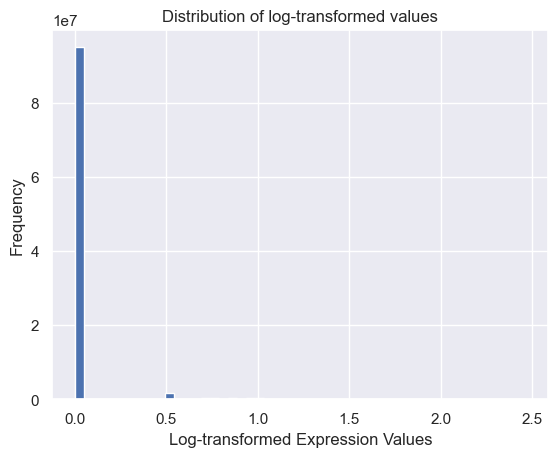

Min: 0.0
Max: 2.46471
Mean: 0.03809172


In [85]:
import numpy as np
import matplotlib.pyplot as plt

# Check the distribution of values
log_values = adata.X.flatten()

plt.hist(log_values, bins=50)
plt.xlabel('Log-transformed Expression Values')
plt.ylabel('Frequency')
plt.title('Distribution of log-transformed values')
plt.show()

# Check summary statistics
print("Min:", np.min(log_values))
print("Max:", np.max(log_values))
print("Mean:", np.mean(log_values))

In [77]:
sc.pp.highly_variable_genes(adata, flavor='seurat_v3', n_top_genes=2000)

/gpfs/gsfs12/users/vasileiosionat2/conda/envs/squidpy/lib/python3.10/site-packages/legacy_api_wrap/__init__.py:82: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  return fn(*args_all, **kw)


In [78]:
adata = adata[:, adata.var['highly_variable']]

adata.X seems to be already log-transformed.
/gpfs/gsfs12/users/vasileiosionat2/conda/envs/squidpy/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:413: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


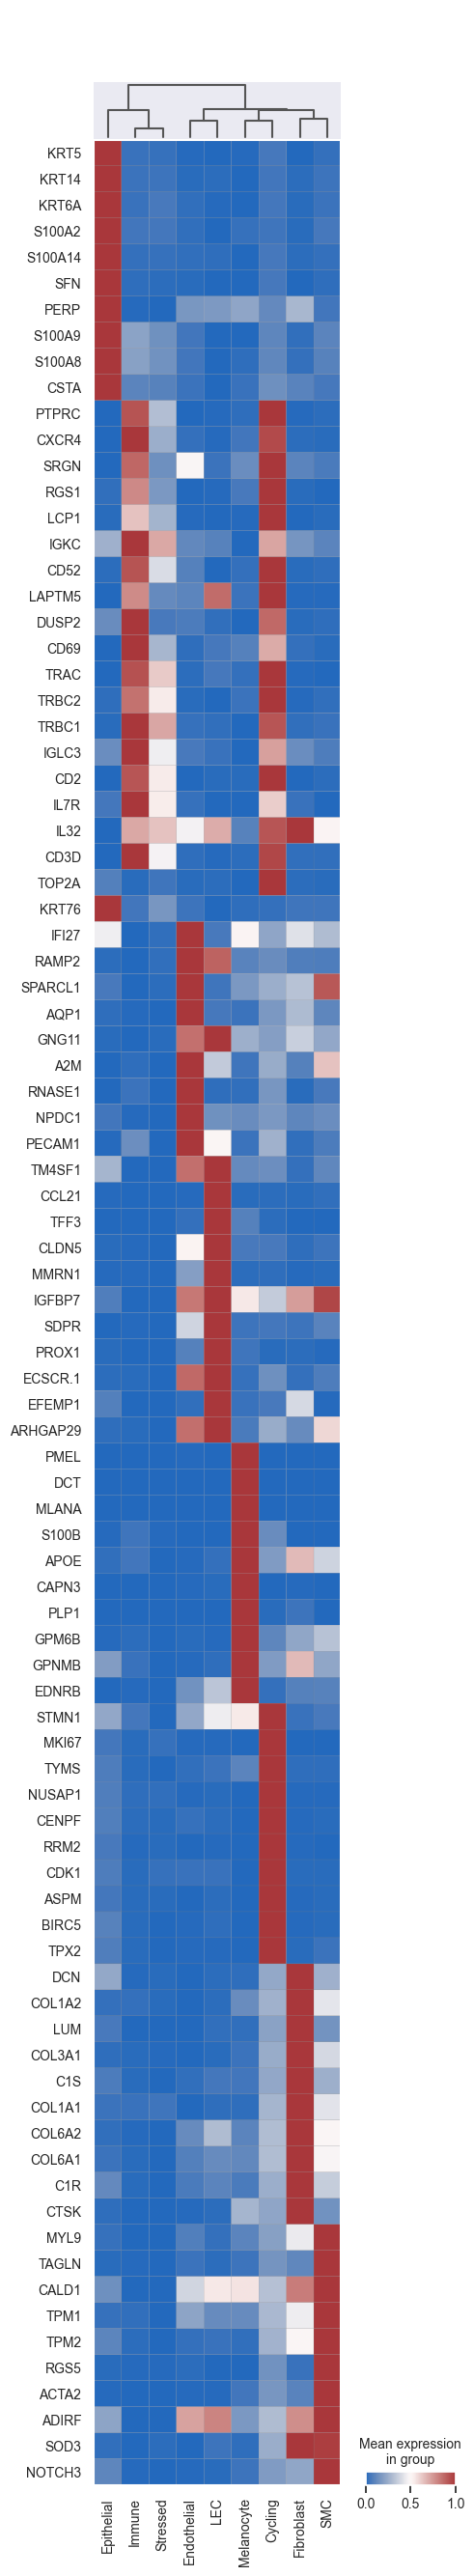

In [79]:
import numpy as np

# Step 3: Log-transform the data if not already done
sc.pp.log1p(adata)

# Step 4: Perform differential expression analysis using the Wilcoxon method
sc.tl.rank_genes_groups(adata, 'generalCellTypes', method='wilcoxon', use_raw=False)

# Step 5: Extract top marker genes for each cluster
top_genes_per_cluster = {}
for cluster in adata.obs['generalCellTypes'].cat.categories:
    top_genes_per_cluster[cluster] = adata.uns['rank_genes_groups']['names'][cluster][:100]  # Top 20 genes

# Step 6: Generate dendrogram for cluster ordering
sc.tl.dendrogram(adata, groupby='generalCellTypes')

# Step 7: Retrieve the cluster order based on the dendrogram
cluster_order = adata.uns['dendrogram_generalCellTypes']['categories_ordered']

# Step 8: Filter genes based on 20% expression threshold
filtered_genes = set()
for cluster in cluster_order:
    cluster_data = adata[adata.obs['generalCellTypes'] == cluster]
    # Calculate the fraction of cells expressing each gene in the cluster
    gene_expression_fraction = np.asarray((cluster_data.X > 0).mean(axis=0)).ravel()
    genes_above_threshold = cluster_data.var_names[gene_expression_fraction > 0.2]
    filtered_genes.update(genes_above_threshold)

# Step 9: Ensure unique genes for plotting
unique_genes = set()
genes_for_plot = []

for cluster in cluster_order:
    if cluster in top_genes_per_cluster:
        cluster_genes = top_genes_per_cluster[cluster]
        genes_for_this_cluster = []
        for gene in cluster_genes:
            if len(genes_for_this_cluster) >= 10:
                break
            if gene in filtered_genes and gene not in unique_genes:
                unique_genes.add(gene)
                genes_for_this_cluster.append(gene)
        genes_for_plot.extend(genes_for_this_cluster)

# Step 10: Plot the dotplot with the filtered genes, swapping axes if necessary
sc.pl.matrixplot(
    adata,
    var_names=genes_for_plot,
    groupby='generalCellTypes',
    dendrogram=True,
    use_raw=False,
    cmap="vlag",
    standard_scale='var',
    swap_axes=True
)

In [81]:
# Check for non-zero small values (e.g., top 10 smallest values)
non_zero_genes = np.nonzero(adata.X.sum(axis=0))[0]
print("Genes with non-zero sums:", non_zero_genes[:10])

# For a specific gene, check its expression values
# Check expression values for the first non-zero gene
gene_idx = non_zero_genes[0]  # Select the first non-zero gene for example
print(f"Expression values for gene {adata.var_names[gene_idx]}: {adata.X[:10, gene_idx]}")  # First 10 cells

Genes with non-zero sums: [0 1 2 3 4 5 6 7 8 9]
Expression values for gene RNF223: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [74]:
# Check the raw data
if adata.raw is not None:
    print(adata.raw.X)

In [51]:
(adata.obs['clusterCellTypes'] == 'B').sum()


np.int64(2645)

In [52]:
# Define the cluster name you want to subset
cluster_name = "gingiva"  # or could be an integer if it's like 0, 1, etc.

# Subset the adata to include only cells of that cluster
adata_gingiva = adata[adata.obs['tissue'] == cluster_name].copy()

In [53]:
(adata_gingiva.obs['clusterCellTypes'] == 'B').sum()

np.int64(2608)

In [54]:
# Define the cluster name you want to subset
cluster_name = "Williams 2021"  # or could be an integer if it's like 0, 1, etc.

# Subset the adata to include only cells of that cluster
adata_Williams_gingiva = adata_gingiva[adata_gingiva.obs['ref'] == cluster_name].copy()

In [55]:
adata.obs['clusterCellTypes'].unique().tolist()

['abT (CD8)',
 'mDC',
 'Monocyte',
 'Fibroblast 1',
 'gd T',
 'Endothelial 1',
 'Epithelial 1',
 'Th17',
 'NK',
 'Melanocyte',
 'SMC',
 'Epithelial 2',
 'abT (CD4)',
 'MAIT',
 'Endothelial 3',
 'Fibroblast 2',
 'Endothelial 2',
 'Mast',
 'LEC',
 'Treg',
 'Cycling',
 'Endothelial 4',
 'Epithelial 3',
 'B',
 'Stressed',
 'Fibroblast 3',
 'Neutrophil',
 'Fibroblast 4',
 'Plasma',
 'pDC']

In [105]:
(adata_Williams_gingiva.obs['clusterCellTypes'] == 'B', 'Plasma').sum()

np.int64(1617)

In [56]:
# Subset the AnnData object to include only samples whose orig.ident starts with "HV" or "TM"
mask = adata_Williams_gingiva.obs['clusterCellTypes'].str.startswith(('B'))
adata_B_Williams_gingiva = adata_Williams_gingiva[mask].copy()

In [57]:
# Subset the AnnData object to include only samples whose orig.ident starts with "HV" or "TM"
mask = adata_B_Williams_gingiva.obs['orig.ident'].str.startswith(('HV', 'TM'))
adata_B_filtered = adata_B_Williams_gingiva[mask].copy()

In [153]:
adata_B_filtered.obs

,orig.ident,nCount_RNA,nFeature_RNA,tech,tissue,status,sex,age,ref,source,...,S.Score,G2M.Score,Phase,old.ident,integrated_snn_res.1,seurat_clusters,clusterCellTypes,generalCellTypes,fineCellTypes,assay
TAAACCGTCGGTGTCG-1_1_1_1_1_1_1_1_1_1_1_1_1_1,HV136,1085.688550,607,10x 3' RNAseq (V3),gingiva,H,F,31,Williams 2021,GSE164241,...,-0.001530,0.020368,G2M,HV136,16,16,B,Immune,B,scSeq
GCAAACTTCGTATCAG-1_2_1_1_1_1_1_1_1_1_1_1_1_1,HV143,6124.732608,2229,10x 3' RNAseq (V3),gingiva,H,F,51,Williams 2021,GSE164241,...,0.069748,0.038874,S,HV143,25,25,B,Immune,B,scSeq
ACGGGTCCAAGCGTAG-1_1_1_1_1_1_1_1_1_1_1_1_1,HV144,864.309677,582,10x 3' RNAseq (V3),gingiva,H,F,61,Williams 2021,GSE164241,...,-0.047299,0.085610,G2M,HV144,16,16,B,Immune,B,scSeq
CGGGTCACAAAGAATC-1_1_1_1_1_1_1_1_1_1_1_1_1,HV144,1030.986967,666,10x 3' RNAseq (V3),gingiva,H,F,61,Williams 2021,GSE164241,...,-0.046440,-0.056660,G1,HV144,16,16,B,Immune,B,scSeq
GAGGTGACAGTCGTGC-1_1_1_1_1_1_1_1_1_1_1_1_1,HV144,279.333001,203,10x 3' RNAseq (V3),gingiva,H,F,61,Williams 2021,GSE164241,...,-0.014627,-0.021764,G1,HV144,16,16,B,Immune,B,scSeq
CGAGAAGAGGGCTCTC-1_2_1_1_1_1_1_1_1_1_1_1_1,HV147,2878.025146,1493,10x 3' RNAseq (V3),gingiva,H,F,37,Williams 2021,GSE164241,...,0.106485,0.246721,G2M,HV147,16,16,B,Immune,B,scSeq
CTCAGAAGTCTTCAAG-1_2_1_1_1_1_1_1_1_1_1_1_1,HV147,689.660540,469,10x 3' RNAseq (V3),gingiva,H,F,37,Williams 2021,GSE164241,...,0.224137,0.047267,S,HV147,16,16,B,Immune,B,scSeq
CTGATCCGTGCGAAAC-1_2_1_1_1_1_1_1_1_1_1_1_1,HV147,716.622923,494,10x 3' RNAseq (V3),gingiva,H,F,37,Williams 2021,GSE164241,...,-0.038698,0.106431,G2M,HV147,16,16,B,Immune,B,scSeq
GAACCTAGTCTTCAAG-1_2_1_1_1_1_1_1_1_1_1_1_1,HV147,679.700054,485,10x 3' RNAseq (V3),gingiva,H,F,37,Williams 2021,GSE164241,...,-0.035401,0.046977,G2M,HV147,16,16,B,Immune,B,scSeq
TACACGAGTCGACTGC-1_2_1_1_1_1_1_1_1_1_1_1_1,HV147,552.695224,393,10x 3' RNAseq (V3),gingiva,H,F,37,Williams 2021,GSE164241,...,-0.000420,-0.053037,G1,HV147,16,16,B,Immune,B,scSeq


In [168]:
adata_B_filtered.var['features'].unique().tolist()

['HES4',
 'ISG15',
 'RNF223',
 'TNFRSF18',
 'TNFRSF4',
 'SCNN1D',
 'MXRA8',
 'VWA1',
 'HES5',
 'ACOT7',
 'UTS2',
 'TNFRSF9',
 'ERRFI1',
 'GPR157',
 'CTNNBIP1',
 'RBP7',
 'ANGPTL7',
 'PDPN',
 'EFHD2',
 'EPHA2',
 'MFAP2',
 'PADI1',
 'NBL1',
 'PLA2G2A',
 'PLA2G2D',
 'CAMK2N1',
 'ALPL',
 'WNT4',
 'C1QA',
 'C1QC',
 'C1QB',
 'FUCA1',
 'STMN1',
 'FAM110D',
 'AIM1L',
 'ZNF683',
 'SFN',
 'FAM46B',
 'FCN3',
 'PTAFR',
 'PHACTR4',
 'LAPTM5',
 'SERINC2',
 'FAM167B',
 'TMEM54',
 'GJA4',
 'CLSPN',
 'CSF3R',
 'CDCA8',
 'RHBDL2',
 'EDN2',
 'SLC2A1',
 'CDC20',
 'KIF2C',
 'TSPAN1',
 'PDZK1IP1',
 'TTC22',
 'DHCR24',
 'PLPP3',
 'TACSTD2',
 'LEPR',
 'SGIP1',
 'GADD45A',
 'DIRAS3',
 'WLS',
 'PTGFR',
 'IFI44L',
 'RP5-887A10.1',
 'CYR61',
 'CLCA2',
 'CLCA4',
 'GBP1',
 'GBP4',
 'GBP5',
 'GBP6',
 'F3',
 'PALMD',
 'VCAM1',
 'COL11A1',
 'CHI3L2',
 'C1orf162',
 'OLFML3',
 'DENND2C',
 'CASQ2',
 'CD2',
 'FAM46C',
 'PHGDH',
 'CH17-373J23.1',
 'GJA5',
 'FCGR1A',
 'ECM1',
 'CTSS',
 'CTSK',
 'ANXA9',
 'TCHH',
 'FLG-AS1',

In [58]:
import scanpy as sc
import numpy as np
from sklearn.cluster import KMeans

np.random.seed(42)

sc.pp.normalize_total(adata_B_filtered, target_sum=1e4)
sc.pp.log1p(adata_B_filtered)
sc.pp.pca(adata_B_filtered, svd_solver='arpack')  # Compute PCA

In [59]:
# Use the top 20 principal components for clustering
X = adata_B_filtered.obsm['X_pca'][:, :20]

# Run K-means
kmeans = KMeans(n_clusters=8, random_state=42)
adata_B_filtered.obs['kmeans'] = kmeans.fit_predict(X).astype(str)  # Store as string labels

In [60]:
sc.pp.neighbors(adata_B_filtered, use_rep='X_pca')
sc.tl.umap(adata_B_filtered)

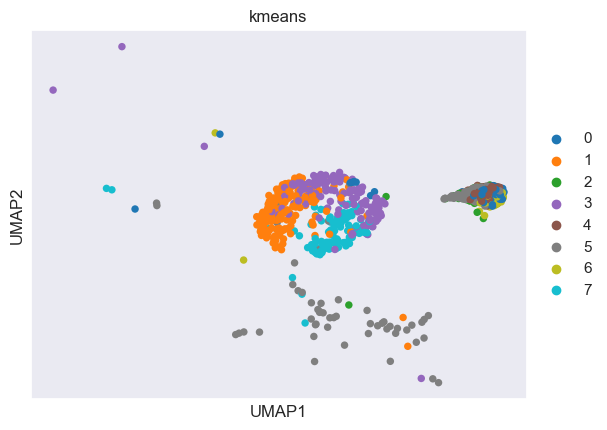

In [61]:
sc.pl.umap(adata_B_filtered, color='kmeans', palette='tab10')

In [64]:
print(adata_B_filtered.obsm['X_pca'])  # Check the PCA embeddings used for clustering
print(adata_B_filtered.obsm['X_umap'])  # Check the UMAP embeddings used for clustering


[[ 10.772758     4.5441384   -5.0048366  ...   4.3718185    2.7633343
    3.7899256 ]
 [ 13.99131    -16.006569   -16.690353   ...  -0.7354198    0.27626488
    1.4054196 ]
 [  9.756213     6.1584125   -5.125967   ...   4.8960967   -2.2977617
    3.1056054 ]
 ...
 [ -8.317601   -10.773397     0.21632172 ...   0.15643317   1.2099756
    0.1872665 ]
 [  7.977677     2.9397168    4.178854   ...  -6.3830194    2.4694445
    9.680222  ]
 [-14.3597355   -4.092134     3.1552598  ...   0.6524126   -0.55487365
   -0.34839165]]
[[ 1.6043805  -0.18595769]
 [ 3.5012684   6.7645755 ]
 [ 2.313331    0.7253372 ]
 ...
 [ 5.1206      5.9660697 ]
 [ 0.72131866  4.016843  ]
 [ 6.8299623   3.7853181 ]]


In [65]:
import scipy.sparse
if isinstance(adata_B_filtered.X, scipy.sparse.spmatrix):
    dense_data = adata_B_filtered.X.toarray()
    print(dense_data.sum(axis=0))  # Check the sum after converting sparse matrix to dense

In [66]:
adata.X

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(50000, 54506), dtype=float32)

In [161]:
(adata_B_filtered.obs['kmeans'] == '0').sum()

np.int64(101)

adata.X seems to be already log-transformed.


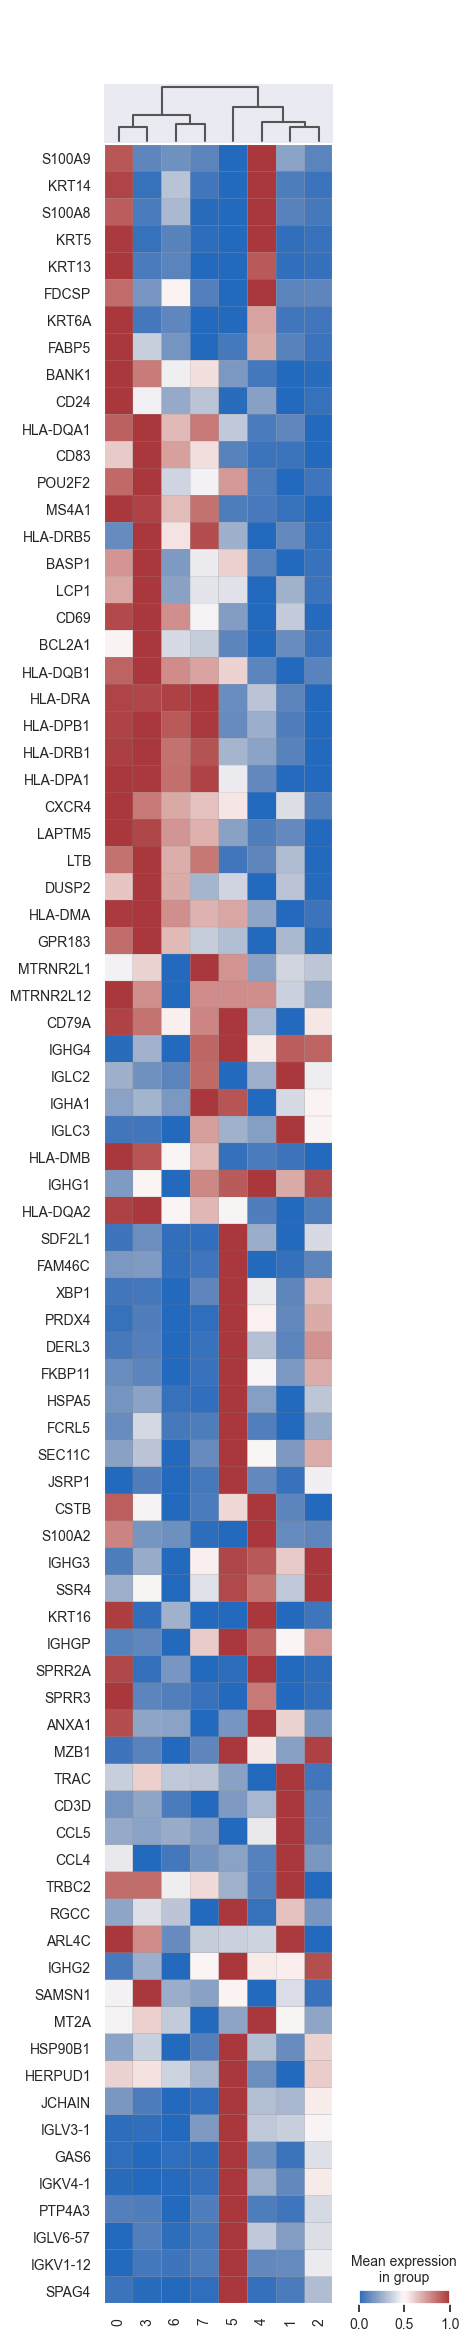

In [166]:
import numpy as np

# Step 3: Log-transform the data if not already done
sc.pp.log1p(adata_B_filtered)

# Step 4: Perform differential expression analysis using the Wilcoxon method
sc.tl.rank_genes_groups(adata_B_filtered, 'kmeans', method='wilcoxon', use_raw=False)

# Step 5: Extract top marker genes for each cluster
top_genes_per_cluster = {}
for cluster in adata_B_filtered.obs['kmeans'].cat.categories:
    top_genes_per_cluster[cluster] = adata_B_filtered.uns['rank_genes_groups']['names'][cluster][:100]  # Top 20 genes

# Step 6: Generate dendrogram for cluster ordering
sc.tl.dendrogram(adata_B_filtered, groupby='kmeans')

# Step 7: Retrieve the cluster order based on the dendrogram
cluster_order = adata_B_filtered.uns['dendrogram_kmeans']['categories_ordered']

# Step 8: Filter genes based on 20% expression threshold
filtered_genes = set()
for cluster in cluster_order:
    cluster_data = adata_B_filtered[adata_B_filtered.obs['kmeans'] == cluster]
    # Calculate the fraction of cells expressing each gene in the cluster
    gene_expression_fraction = np.asarray((cluster_data.X > 0).mean(axis=0)).ravel()
    genes_above_threshold = cluster_data.var_names[gene_expression_fraction > 0.2]
    filtered_genes.update(genes_above_threshold)

# Step 9: Ensure unique genes for plotting
unique_genes = set()
genes_for_plot = []

for cluster in cluster_order:
    if cluster in top_genes_per_cluster:
        cluster_genes = top_genes_per_cluster[cluster]
        genes_for_this_cluster = []
        for gene in cluster_genes:
            if len(genes_for_this_cluster) >= 10:
                break
            if gene in filtered_genes and gene not in unique_genes:
                unique_genes.add(gene)
                genes_for_this_cluster.append(gene)
        genes_for_plot.extend(genes_for_this_cluster)

# Step 10: Plot the dotplot with the filtered genes, swapping axes if necessary
sc.pl.matrixplot(
    adata_B_filtered,
    var_names=genes_for_plot,
    groupby='kmeans',
    dendrogram=True,
    use_raw=False,
    cmap="vlag",
    standard_scale='var',
    swap_axes=True
)

In [110]:
sc.pp.filter_genes(adata_B_final, min_cells=10)  # remove genes expressed in <3 cells

In [8]:
print(sc.__version__)

1.11.3


In [9]:
!pip install --user scikit-misc

In [111]:
sc.pp.highly_variable_genes(adata_B_final, flavor='seurat_v3', n_top_genes=2000)

/gpfs/gsfs12/users/vasileiosionat2/conda/envs/squidpy/lib/python3.10/site-packages/legacy_api_wrap/__init__.py:82: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  return fn(*args_all, **kw)


In [112]:
adata_B_final = adata_B_final[:, adata_B_final.var['highly_variable']]

In [114]:
adata_B_final.obs['orig.ident'].unique().tolist()

['HV136',
 'HV143',
 'HV144',
 'HV147',
 'HV148',
 'HV169G',
 'TM183',
 'TM238',
 'TM241',
 'TM242',
 'TM283',
 'TM289',
 'HV134',
 'HV153',
 'HV161',
 'HV161b',
 'HV164',
 'HV164b',
 'HV170']

adata.X seems to be already log-transformed.
/gpfs/gsfs12/users/vasileiosionat2/conda/envs/squidpy/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:413: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
Dendrogram not added. Dendrogram is added only when the number of categories to plot > 2


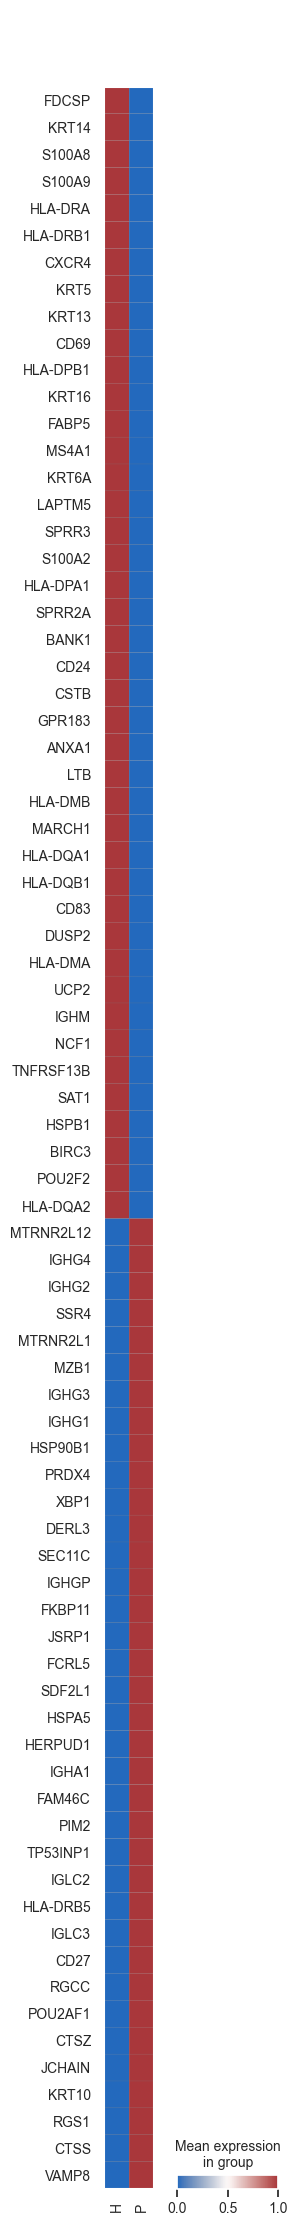

In [115]:
import numpy as np

# Step 3: Log-transform the data if not already done
sc.pp.log1p(adata_B_final)

# Step 4: Perform differential expression analysis using the Wilcoxon method
sc.tl.rank_genes_groups(adata_B_final, 'status', method='wilcoxon', use_raw=False)

# Step 5: Extract top marker genes for each cluster
top_genes_per_cluster = {}
for cluster in adata_B_final.obs['status'].cat.categories:
    top_genes_per_cluster[cluster] = adata_B_final.uns['rank_genes_groups']['names'][cluster][:100]  # Top 20 genes

# Step 6: Generate dendrogram for cluster ordering
sc.tl.dendrogram(adata_B_final, groupby='status')

# Step 7: Retrieve the cluster order based on the dendrogram
cluster_order = adata_B_final.uns['dendrogram_status']['categories_ordered']

# Step 8: Filter genes based on 20% expression threshold
filtered_genes = set()
for cluster in cluster_order:
    cluster_data = adata_B_final[adata_B_final.obs['status'] == cluster]
    # Calculate the fraction of cells expressing each gene in the cluster
    gene_expression_fraction = np.asarray((cluster_data.X > 0).mean(axis=0)).ravel()
    genes_above_threshold = cluster_data.var_names[gene_expression_fraction > 0.2]
    filtered_genes.update(genes_above_threshold)

# Step 9: Ensure unique genes for plotting
unique_genes = set()
genes_for_plot = []

for cluster in cluster_order:
    if cluster in top_genes_per_cluster:
        cluster_genes = top_genes_per_cluster[cluster]
        genes_for_this_cluster = []
        for gene in cluster_genes:
            if len(genes_for_this_cluster) >= 50:
                break
            if gene in filtered_genes and gene not in unique_genes:
                unique_genes.add(gene)
                genes_for_this_cluster.append(gene)
        genes_for_plot.extend(genes_for_this_cluster)

# Step 10: Plot the dotplot with the filtered genes, swapping axes if necessary
sc.pl.matrixplot(
    adata_B_final,
    var_names=genes_for_plot,
    groupby='status',
    dendrogram=True,
    use_raw=False,
    cmap="vlag",
    standard_scale='var',
    swap_axes=True
)

In [17]:
print(genes_for_plot)

['FDCSP', 'LUM', 'CLU', 'SEPP1', 'TM4SF1', 'SERPINF1', 'PLAC9', 'CLDN5', 'CXCL14', 'C1S', 'COL1A2', 'SOD3', 'MT2A', 'HSPB1', 'ACKR1', 'TIMP3', 'ID1', 'FBLN2', 'IGFBP5', 'PCOLCE', 'GLUL', 'COL1A1', 'CTHRC1', 'CCL2', 'FBLN1', 'HLA-DRA', 'CTSK', 'MT1X', 'IGFBP2', 'NBL1', 'C1R', 'RARRES2', 'CXCL12', 'MGP', 'ANXA1', 'COL6A2', 'CLEC14A', 'MMP2', 'CXCL2', 'CTGF', 'COL6A3', 'COL6A1', 'MT1E', 'PLVAP', 'EIF4E', 'EMP1', 'S100A16', 'MYL9', 'CLEC2B', 'HYAL2', 'MTRNR2L12', 'IGHG3', 'HSP90B1', 'SSR4', 'IGHG1', 'IGHG4', 'MTRNR2L1', 'CSTB', 'S100A9', 'PLCG2', 'SEC11C', 'HSPA5', 'IGHA1', 'MZB1', 'S100A8', 'IGLC2', 'IGHG2', 'XBP1', 'CSTA', 'LCP1', 'IER3', 'SDF2L1', 'EFHD2', 'CTSS', 'SPRR2A', 'KRT13', 'FKBP11', 'TXN', 'KRT10', 'CTSZ', 'STAT1', 'CCND2', 'HN1', 'ARL4C', 'FABP5', 'ZNF331', 'TXNDC17', 'S100A2', 'PRDX4', 'PMEPA1', 'HERPUD1', 'VAMP8', 'KRT6A', 'ATF3', 'FILIP1L', 'RGS1', 'SERPINB1', 'COL4A1', 'HIST1H4C', 'H2AFJ']


In [184]:
import numpy as np
import pandas as pd
from scipy.stats import ranksums
from statsmodels.stats.multitest import multipletests


# Extract indices for Crevicular and Oral groups
healthy_indices = adata_B_final.obs['status'] == 'H'
perio_indices = adata_B_final.obs['status'] == 'P'

# Extract expression data for Crevicular and Oral groups
healthy_expr = adata_B_final[healthy_indices, :].X.toarray()
perio_expr = adata_B_final[perio_indices, :].X.toarray()

# Initialize lists to store results
gene_names = []  # List for gene names
log2fc = []
p_values = []

epsilon = 1e-10  # Avoid division by zero

for gene in range(healthy_expr.shape[1]):
    healthy_gene_expression = healthy_expr[:, gene]
    perio_gene_expression = perio_expr[:, gene]

    if np.all(healthy_gene_expression == 0) and np.all(perio_gene_expression == 0):
        log2fc.append(np.nan)
        p_values.append(np.nan)
        gene_names.append(adata_B_final.var_names[gene])
        continue

    # Perform Wilcoxon test
    try:
        stat, p_val = ranksums(healthy_gene_expression, perio_gene_expression)
    except:
        p_val = np.nan

    mean_healthy = np.mean(healthy_gene_expression)
    mean_perio = np.mean(perio_gene_expression)
    log2_fold_change = np.log2((mean_healthy + epsilon) / (mean_perio + epsilon))

    log2fc.append(log2_fold_change)
    p_values.append(p_val)
    gene_names.append(adata_B_final.var_names[gene])

# Step 3: Adjust p-values for multiple testing using Benjamini-Hochberg correction
_, p_values_adj, _, _ = multipletests(p_values, method='fdr_bh')

dge_results = pd.DataFrame({
    'Gene Name': gene_names,
    'Log2 Fold Change (Healthy vs Perio)': log2fc,
    'P-Value': p_values,
    'Adjusted P-Value (FDR)': p_values_adj
})

# Step 5: Display the top significant genes (optional, based on FDR)
# You can filter based on your preferred significance threshold (e.g., FDR < 0.05)
significant_genes = dge_results[dge_results['Adjusted P-Value (FDR)'] < 0.01]

# Display results
print(dge_results.head())  # Show the first few results
print(f"Number of significant genes (FDR < 0.01): {len(significant_genes)}")

  Gene Name  Log2 Fold Change (Healthy vs Perio)   P-Value  \
0     ISG15                            -0.053551  0.951817   
1  TNFRSF18                            -1.921969  0.226540   
2   TNFRSF4                            -1.748342  0.572192   
3  CTNNBIP1                             0.407385  0.825975   
4     EFHD2                            -0.593418  0.418630   

   Adjusted P-Value (FDR)  
0                0.998742  
1                0.696352  
2                0.995766  
3                0.995766  
4                0.995766  
Number of significant genes (FDR < 0.01): 69


In [117]:
dge_results

,Gene Name,Log2 Fold Change (Healthy vs Perio),P-Value,Adjusted P-Value (FDR)
0,ISG15,-0.067879,9.518174e-01,9.987418e-01
1,TNFRSF18,-1.934434,2.265396e-01,6.963519e-01
2,TNFRSF4,-1.771284,5.721924e-01,9.957663e-01
3,CTNNBIP1,0.404980,8.259747e-01,9.957663e-01
4,EFHD2,-0.597215,4.186299e-01,9.957663e-01
5,C1QA,0.323105,9.508286e-01,9.987418e-01
6,FUCA1,-0.583257,7.290368e-01,9.957663e-01
7,STMN1,0.636922,5.569476e-01,9.957663e-01
8,SFN,3.898784,1.428397e-01,4.985565e-01
9,PTAFR,1.604625,4.965144e-01,9.957663e-01


In [118]:
# Assuming dge_results is the dataframe containing statistics results (with 'pvalue' column)
pval_0 = dge_results[dge_results['Adjusted P-Value (FDR)'] == 0]

In [119]:
# Creating a jittered list of very small p-values around 1e-300
pval_jitter = np.round(np.random.normal(loc=295, scale=5, size=pval_0.shape[0]), 0)
pval_jitter = 1 * 10 ** -pval_jitter

In [120]:
# Set pandas display option to show all rows
pd.set_option('display.max_rows', None)  # Display all rows

# Display full results of significant genes
print(significant_genes)

    Gene Name  Log2 Fold Change (Healthy vs Perio)       P-Value  \
11     LAPTM5                             0.785529  5.315150e-12   
22     FAM46C                            -1.094108  1.480024e-05   
28      SPRR3                             5.175040  8.788724e-11   
31     SPRR2A                             4.592393  2.346244e-08   
34     S100A9                             2.715804  2.483157e-29   
35     S100A8                             2.979848  8.412229e-34   
37     S100A2                             3.039526  2.954785e-10   
42      FCRL5                            -1.616080  4.735066e-09   
66       SDC1                            -1.844993  4.346803e-04   
88      CXCR4                             0.530316  3.162167e-20   
121     FDCSP                             2.960449  2.483605e-43   
133     BANK1                             0.878593  2.408486e-08   
135    MARCH1                             1.278892  1.836294e-04   
150      MZB1                            -1.1977

In [124]:
# Filter for rows with fold change > 2 or < -2
filtered_genes = significant_genes[(significant_genes['Log2 Fold Change (Healthy vs Perio)'] > 0.5) | 
                                  (significant_genes['Log2 Fold Change (Healthy vs Perio)'] < -0.5)]

print("\nFiltered Most Significant Genes:")
print(filtered_genes[['Gene Name', 'Log2 Fold Change (Healthy vs Perio)', 'Adjusted P-Value (FDR)']])


Filtered Most Significant Genes:
    Gene Name  Log2 Fold Change (Healthy vs Perio)  Adjusted P-Value (FDR)
11     LAPTM5                             0.785529            9.915505e-11
22     FAM46C                            -1.094108            1.740636e-04
28      SPRR3                             5.175040            1.533774e-09
31     SPRR2A                             4.592393            3.428923e-07
34     S100A9                             2.715804            2.686776e-27
35     S100A8                             2.979848            1.137754e-31
37     S100A2                             3.039526            4.995434e-09
42      FCRL5                            -1.616080            7.319059e-08
66       SDC1                            -1.844993            3.855115e-03
88      CXCR4                             0.530316            1.425610e-18
121     FDCSP                             2.960449            1.343631e-40
133     BANK1                             0.878593            3.42

In [41]:
!pip install adjustText

In [47]:
!pip install brokenaxes 

In [122]:
# Step 3: Top 20 genes up in Healthy
top_healthy = (
    filtered_genes[filtered_genes['Log2 Fold Change (Healthy vs Perio)'] > 0]
    .sort_values('Adjusted P-Value (FDR)')
    .head(20)['Gene Name']
)

# Step 4: Top 20 genes up in Perio
top_perio = (
    filtered_genes[filtered_genes['Log2 Fold Change (Healthy vs Perio)'] < 0]
    .sort_values('Adjusted P-Value (FDR)')
    .head(20)['Gene Name']
)

# Step 5: Combine into single annotation list
genes_of_interest = list(set(top_healthy).union(set(top_perio)))

print(f"Total genes of interest (filtered + top 20 per group): {len(genes_of_interest)}")


Total genes of interest (filtered + top 20 per group): 40


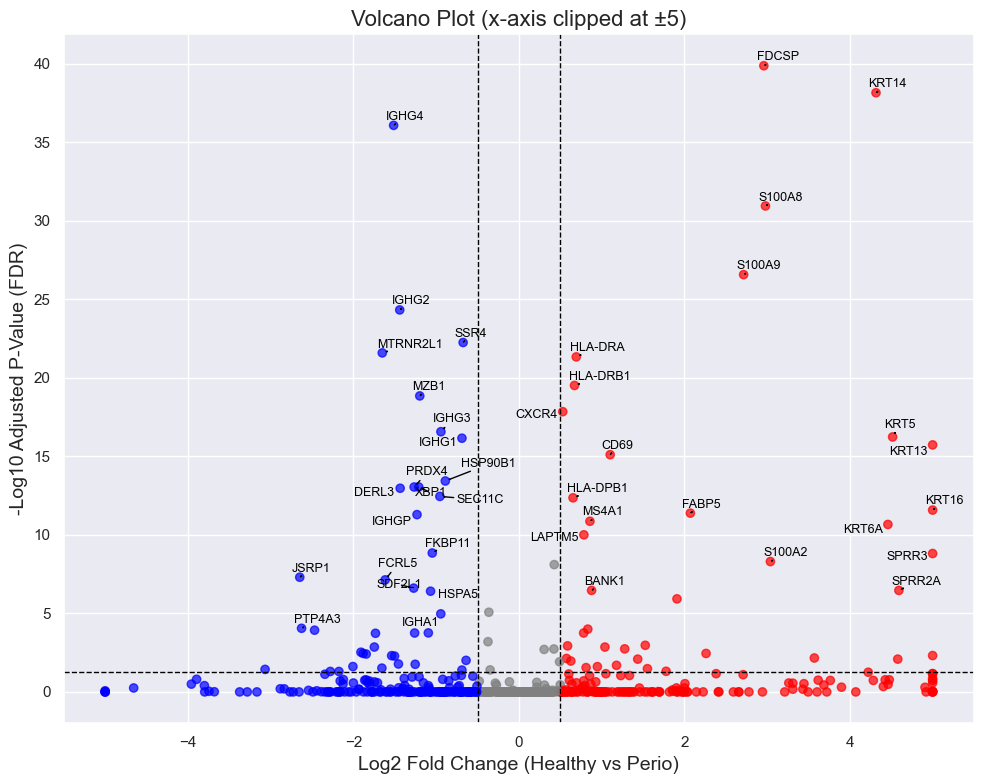

In [126]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from adjustText import adjust_text

# Step 1: Define data source
log2fc_values = dge_results['Log2 Fold Change (Healthy vs Perio)'].values
log10_pvalues = -np.log10(np.maximum(dge_results['Adjusted P-Value (FDR)'].values, 1e-300))
gene_names = dge_results['Gene Name'].values

# Step 4: Clip x-values for visualization, keep originals for annotation
x_clipped = np.clip(log2fc_values, -5, 5)

# Step 5: Define colors based on original log2FC
colors = ['red' if fc > 0.5 else 'blue' if fc < -0.5 else 'grey' for fc in log2fc_values]

# Step 6: Plot
fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(x_clipped, log10_pvalues, c=colors, alpha=0.7)

# Step 7: Annotate genes of interest using true log2FC (not clipped)
texts = []
for x_true, x_plot, y, name in zip(log2fc_values, x_clipped, log10_pvalues, gene_names):
    if name in genes_of_interest:
        texts.append(ax.text(x_plot, y, name, fontsize=9, color='black', ha='right'))

# Adjust annotations to reduce overlap
adjust_text(texts, only_move={'points': 'xy', 'text': 'xy'},
            arrowprops=dict(arrowstyle='->', color='black'))

# Step 8: Add axis lines
ax.axhline(-np.log10(0.05), linestyle='--', color='black', linewidth=1)
ax.axvline(0.5, linestyle='--', color='black', linewidth=1)
ax.axvline(-0.5, linestyle='--', color='black', linewidth=1)

# Step 9: Labels and title
ax.set_xlim(-5.5, 5.5)
ax.set_xlabel('Log2 Fold Change (Healthy vs Perio)', fontsize=14)
ax.set_ylabel('-Log10 Adjusted P-Value (FDR)', fontsize=14)
ax.set_title('Volcano Plot (x-axis clipped at ±5)', fontsize=16)

plt.tight_layout()
plt.show()


In [57]:
import pandas as pd

# Load the compressed TSV file
df = pd.read_csv('/data/vasileiosionat2/scRNAseq/PanglaoDB.tsv.gz', 
                 sep='\t', 
                 compression='gzip')

# Preview the first 5 rows
print(df.head())


  species official gene symbol     cell type           nicknames  \
0   Mm Hs                CTRB1  Acinar cells                CTRB   
1   Mm Hs                 KLK1  Acinar cells                Klk6   
2   Mm Hs                RBPJL  Acinar cells  RBP-L|SUHL|RBPSUHL   
3   Mm Hs                PTF1A  Acinar cells    PTF1-p48|bHLHa29   
4      Mm                 TRY4  Acinar cells                 NaN   

   ubiquitousness index                                product description  \
0                 0.017                                chymotrypsinogen B1   
1                 0.013                                       kallikrein 1   
2                 0.001  recombination signal binding protein for immun...   
3                 0.001        pancreas associated transcription factor 1a   
4                 0.007                                          trypsin 4   

             gene type  canonical marker germ layer     organ  \
0  protein-coding gene               1.0   Endoderm  Panc

In [58]:
# Replace 'column_name' with your actual column name
print(df['species'].unique())

['Mm Hs' 'Mm' 'Hs' nan '4']


In [61]:
# Replace 'column_name' and 'desired_categories' with yours
filtered_df = df[df['species'].isin(['Mm Hs', 'Hs'])]

In [60]:
# Replace 'column_name' with your actual column name
print(df['cell type'].unique())

['Acinar cells' 'Adipocyte progenitor cells' 'Adipocytes'
 'Adrenergic neurons' 'Airway epithelial cells' 'Airway goblet cells'
 'Airway smooth muscle cells' 'Alpha cells' 'Alveolar macrophages'
 'Anterior pituitary gland cells' 'Astrocytes' 'B cells' 'B cells memory'
 'B cells naive' 'Basal cells' 'Basophils' 'Bergmann glia' 'Beta cells'
 'Cajal-Retzius cells' 'Cardiac stem and precursor cells' 'Cardiomyocytes'
 'Cholangiocytes' 'Cholinergic neurons' 'Chondrocytes'
 'Choroid plexus cells' 'Chromaffin cells' 'Ciliated cells' 'Clara cells'
 'Crypt cells' 'Decidual cells' 'Delta cells' 'Dendritic cells'
 'Distal tubule cells' 'Dopaminergic neurons' 'Ductal cells'
 'Embryonic stem cells' 'Endothelial cells' 'Endothelial cells (aorta)'
 'Endothelial cells (blood brain barrier)' 'Enteric glia cells'
 'Enteric neurons' 'Enterochromaffin cells' 'Enterocytes'
 'Enteroendocrine cells' 'Eosinophils' 'Ependymal cells' 'Epiblast cells'
 'Epithelial cells' 'Epsilon cells' 'Erythroblasts'
 'Erythroi

In [62]:
# Replace 'column_name' and 'desired_categories' with yours
filtered_df2 = filtered_df[filtered_df['cell type'].isin(['B cells', 'B cells memory', 'B cells naive'])]

In [67]:
# Replace 'column_name' with your actual column name
print(filtered_df2['official gene symbol'].unique())

['CD2' 'CD5' 'MS4A1' 'CR2' 'CD22' 'FCER2' 'CD40' 'CD69' 'CD70' 'CD79A'
 'CD79B' 'CD80' 'CD86' 'TNFRSF9' 'SDC1' 'TNFSF4' 'TNFRSF13B' 'TNFRSF13C'
 'PDCD1' 'IGHD' 'IGHM' 'RASGRP3' 'HLA-DRA' 'LTB' 'HLA-DQA1' 'FLI1' 'CD14'
 'SEMA6D' 'LAIR1' 'IFIT3' 'IGLL1' 'DNTT' 'MME' 'SPN' 'CD19' 'CD24' 'CD27'
 'B3GAT1' 'CD72' 'MUM1' 'PAX5' 'JCHAIN' 'MZB1' 'LY6D' 'FCMR' 'BANK1'
 'EDEM1' 'VPREB3' 'POU2AF1' 'CRELD2' 'DERL3' 'RALGPS2' 'FCHSD2' 'POLD4'
 'TNFRSF17' 'HVCN1' 'FCRLA' 'EDEM2' 'BLNK' 'TXNDC11' 'BTLA' 'SMAP2'
 'FKBP11' 'SEC61A1' 'SPCS3' 'SPIB' 'EAF2' 'CXCR4' 'BIRC3' 'IGLC2' 'IGLC3'
 'IGLC1' 'IL21R' 'IGKC' 'VPREB1' 'LRMP' 'KLHL6' 'SLAMF6' 'FAM129C' 'BST1'
 'MSH5' 'DOK3' 'BACH2' 'PXK' 'IGHG1' 'IGHG3' 'IGHG4' 'CD38' 'PTPRC' 'EBF1'
 'BCL11A' 'CCR7' 'CD55' 'CD74' 'CD52' 'TLR9' 'SWAP70' 'HMGA1' 'CD84'
 'NT5E' 'ADAM28' 'AIM2' 'ALOX5' 'BLK' 'CCR6' 'CD180' 'CD1C' 'CD37'
 'CLCA3P' 'CXCR5' 'DENND5B' 'FCGR2B' 'FCRL2' 'FRK' 'GNG7' 'GPR18'
 'GUSBP11' 'HHEX' 'HLA-DOB' 'IFNA10' 'IGLL3P' 'IL7' 'IRF8' 'LY86' 'MBL2'
 

In [68]:
bcell_genes = ['CD2' 'CD5' 'MS4A1' 'CR2' 'CD22' 'FCER2' 'CD40' 'CD69' 'CD70' 'CD79A'
 'CD79B' 'CD80' 'CD86' 'TNFRSF9' 'SDC1' 'TNFSF4' 'TNFRSF13B' 'TNFRSF13C'
 'PDCD1' 'IGHD' 'IGHM' 'RASGRP3' 'HLA-DRA' 'LTB' 'HLA-DQA1' 'FLI1' 'CD14'
 'SEMA6D' 'LAIR1' 'IFIT3' 'IGLL1' 'DNTT' 'MME' 'SPN' 'CD19' 'CD24' 'CD27'
 'B3GAT1' 'CD72' 'MUM1' 'PAX5' 'JCHAIN' 'MZB1' 'LY6D' 'FCMR' 'BANK1'
 'EDEM1' 'VPREB3' 'POU2AF1' 'CRELD2' 'DERL3' 'RALGPS2' 'FCHSD2' 'POLD4'
 'TNFRSF17' 'HVCN1' 'FCRLA' 'EDEM2' 'BLNK' 'TXNDC11' 'BTLA' 'SMAP2'
 'FKBP11' 'SEC61A1' 'SPCS3' 'SPIB' 'EAF2' 'CXCR4' 'BIRC3' 'IGLC2' 'IGLC3'
 'IGLC1' 'IL21R' 'IGKC' 'VPREB1' 'LRMP' 'KLHL6' 'SLAMF6' 'FAM129C' 'BST1'
 'MSH5' 'DOK3' 'BACH2' 'PXK' 'IGHG1' 'IGHG3' 'IGHG4' 'CD38' 'PTPRC' 'EBF1'
 'BCL11A' 'CCR7' 'CD55' 'CD74' 'CD52' 'TLR9' 'SWAP70' 'HMGA1' 'CD84'
 'NT5E' 'ADAM28' 'AIM2' 'ALOX5' 'BLK' 'CCR6' 'CD180' 'CD1C' 'CD37'
 'CLCA3P' 'CXCR5' 'DENND5B' 'FCGR2B' 'FCRL2' 'FRK' 'GNG7' 'GPR18'
 'GUSBP11' 'HHEX' 'HLA-DOB' 'IFNA10' 'IGLL3P' 'IL7' 'IRF8' 'LY86' 'MBL2'
 'NMBR' 'NPIPB15' 'P2RX5' 'PNOC' 'PTPRCAP' 'RASGRP2' 'SIK1' 'SIT1'
 'SLC12A1' 'SP140' 'STAP1' 'TMEM156' 'TRAF4' 'ZBTB32' 'IL2RA' 'ABCB4'
 'BCL7A' 'BEND5' 'BRAF' 'IL4R' 'MEP1A' 'MICAL3' 'P2RY14' 'PSG2' 'SELL'
 'TCL1A' 'UGT1A8' 'ZNF286A' 'TNFSF8' 'FOXP1' 'MITF' 'HLA-DQB1' 'LINC00926'
 'STAG3']

In [169]:
!pip install biomart

In [170]:
go_ids_of_interest = {
    # Antigen presentation
    'GO:0019882', 'GO:0048002', 'GO:0002504', 'GO:0002474',
    # B cell activation
    'GO:0042113', 'GO:0002322', 'GO:0050864',
    # Chemotaxis / adhesion
    'GO:0006935', 'GO:0007155', 'GO:0002685', 'GO:0030155',
    # IFN signaling
    'GO:0060337', 'GO:0034340', 'GO:0045071', 'GO:0051607',
    # Proliferation
    'GO:0008283', 'GO:0042127', 'GO:0051726', 'GO:0000086',
    # Class-switching / Ig production
    'GO:0045190', 'GO:0016064', 'GO:0002377', 'GO:0002313'
}

In [171]:
from biomart import BiomartServer
import pandas as pd
from io import StringIO

# Connect to Ensembl BioMart
server = BiomartServer("http://www.ensembl.org/biomart")
dataset = server.datasets['hsapiens_gene_ensembl']

# Query BioMart for genes annotated to your GO terms
response = dataset.search({
    'filters': {
        'go': list(go_ids_of_interest)
    },
    'attributes': [
        'external_gene_name', 'ensembl_gene_id', 'go_id', 'name_1006', 'namespace_1003'
    ]
})

# Convert to DataFrame
go_df = pd.read_csv(StringIO(response.text), sep='\t', header=None)
go_df.columns = ['gene_name', 'ensembl_id', 'go_id', 'go_term', 'go_domain']

In [186]:
# Match with gene names in your AnnData
matching_genes = [g for g in go_df['gene_name'].unique() if g in adata_B_filtered.var_names]

# Best practice order:
sc.pp.normalize_total(adata_B_filtered, target_sum=1e4)
sc.pp.log1p(adata_B_filtered)

# Only then subset to relevant genes
adata_B_filtered = adata_B_filtered[:, matching_genes].copy()

adata.X seems to be already log-transformed.


In [178]:
adata_B_filtered.var['features'].unique().tolist()

['AURKA',
 'CCNA2',
 'PLK1',
 'ABCB1',
 'CDK1',
 'CCNB1',
 'GPR183',
 'FCGR2B',
 'GAPT',
 'HLA-DMB',
 'HLA-DMA',
 'HLA-DQA2',
 'HLA-DQB2',
 'HLA-DRA',
 'HLA-DPA1',
 'HLA-DQA1',
 'HLA-DQB1',
 'HLA-DPB1',
 'HLA-DRB1',
 'HLA-DRB5',
 'SMPD3',
 'ANXA1',
 'CCL17',
 'CCL22',
 'CXCL6',
 'PTAFR',
 'FLT1',
 'PLAUR',
 'MSMP',
 'C5AR1',
 'PLAU',
 'RNASE2',
 'PROK2',
 'DEFB4A',
 'DEFB1',
 'HMGB2',
 'PDGFRB',
 'ENPP2',
 'XCL2',
 'CCL3L3',
 'CCL18',
 'CCL3',
 'CCL4',
 'CCL4L2',
 'XCL1',
 'FPR3',
 'CCL19',
 'CTSG',
 'CCL23',
 'ACKR3',
 'CCL5',
 'RARRES2',
 'CXCL17',
 'CMTM2',
 'CXCL2',
 'CCL20',
 'CXCL9',
 'CXCL10',
 'CXCL11',
 'CXCL13',
 'ACKR4',
 'CXCL1',
 'CXCL5',
 'CXCL3',
 'CCL26',
 'CCR6',
 'CCR1',
 'CXCL14',
 'CCL7',
 'CCL11',
 'CCL8',
 'CCL13',
 'CCL1',
 'CCL2',
 'CXCL12',
 'CCL21',
 'FPR1',
 'PDGFRA',
 'PPBP',
 'C3AR1',
 'CCL14',
 'CX3CR1',
 'CXCL8',
 'CXCR4',
 'ROBO2',
 'XCR1',
 'CCR7',
 'S100A9',
 'S100A8',
 'CXADR',
 'POSTN',
 'PCDH17',
 'CDH19',
 'SRPX',
 'DSG3',
 'SEMA5A',
 'OLR1',
 'ITG

adata.X seems to be already log-transformed.
Dendrogram not added. Dendrogram is added only when the number of categories to plot > 2


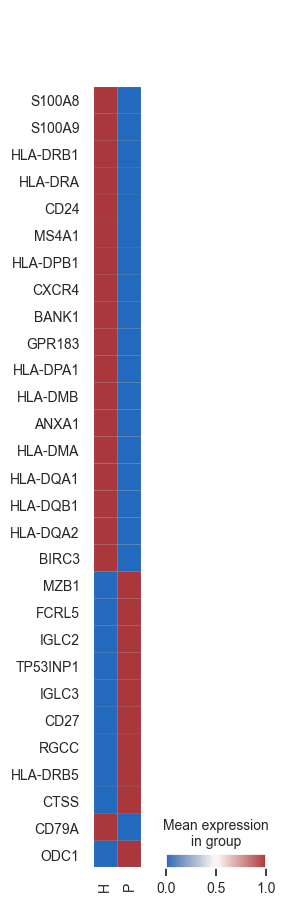

In [179]:
import numpy as np

# Step 3: Log-transform the data if not already done
sc.pp.log1p(adata_B_filtered)

# Step 4: Perform differential expression analysis using the Wilcoxon method
sc.tl.rank_genes_groups(adata_B_filtered, 'status', method='wilcoxon', use_raw=False)

# Step 5: Extract top marker genes for each cluster
top_genes_per_cluster = {}
for cluster in adata_B_filtered.obs['status'].cat.categories:
    top_genes_per_cluster[cluster] = adata_B_filtered.uns['rank_genes_groups']['names'][cluster][:100]  # Top 20 genes

# Step 6: Generate dendrogram for cluster ordering
sc.tl.dendrogram(adata_B_filtered, groupby='status')

# Step 7: Retrieve the cluster order based on the dendrogram
cluster_order = adata_B_filtered.uns['dendrogram_status']['categories_ordered']

# Step 8: Filter genes based on 20% expression threshold
filtered_genes = set()
for cluster in cluster_order:
    cluster_data = adata_B_filtered[adata_B_filtered.obs['status'] == cluster]
    # Calculate the fraction of cells expressing each gene in the cluster
    gene_expression_fraction = np.asarray((cluster_data.X > 0).mean(axis=0)).ravel()
    genes_above_threshold = cluster_data.var_names[gene_expression_fraction > 0.2]
    filtered_genes.update(genes_above_threshold)

# Step 9: Ensure unique genes for plotting
unique_genes = set()
genes_for_plot = []

for cluster in cluster_order:
    if cluster in top_genes_per_cluster:
        cluster_genes = top_genes_per_cluster[cluster]
        genes_for_this_cluster = []
        for gene in cluster_genes:
            if len(genes_for_this_cluster) >= 50:
                break
            if gene in filtered_genes and gene not in unique_genes:
                unique_genes.add(gene)
                genes_for_this_cluster.append(gene)
        genes_for_plot.extend(genes_for_this_cluster)

# Step 10: Plot the dotplot with the filtered genes, swapping axes if necessary
sc.pl.matrixplot(
    adata_B_filtered,
    var_names=genes_for_plot,
    groupby='status',
    dendrogram=True,
    use_raw=False,
    cmap="vlag",
    standard_scale='var',
    swap_axes=True
)

In [185]:
adata_B_filtered.var

,features,n_cells,highly_variable,highly_variable_rank,means,variances,variances_norm
AURKA,AURKA,411,True,1416.0,0.005205,0.001977,0.942990
CCNA2,CCNA2,275,True,1194.0,0.003526,0.001368,0.962021
PLK1,PLK1,179,True,1151.0,0.002311,0.000906,0.964810
ABCB1,ABCB1,2903,True,1177.0,0.038650,0.014261,0.963149
CDK1,CDK1,615,True,916.0,0.007991,0.003144,0.983555
CCNB1,CCNB1,545,True,996.0,0.007030,0.002756,0.977130
GPR183,GPR183,5111,True,748.0,0.072960,0.027263,1.000211
FCGR2B,FCGR2B,1241,True,961.0,0.016244,0.006243,0.980193
GAPT,GAPT,550,True,1557.0,0.006886,0.002565,0.928211
HLA-DMB,HLA-DMB,3127,True,1142.0,0.041749,0.015426,0.965392


In [189]:
import numpy as np
import pandas as pd
from scipy.stats import ranksums
from statsmodels.stats.multitest import multipletests

# Extract indices for Crevicular and Oral groups
healthy_indices = adata_B_filtered.obs['status'] == 'H'
perio_indices = adata_B_filtered.obs['status'] == 'P'

# Extract expression data
healthy_expr = adata_B_filtered[healthy_indices, :].X.toarray()
perio_expr = adata_B_filtered[perio_indices, :].X.toarray()

# Initialize lists
gene_names = []
log2fc = []
p_values = []

epsilon = 1e-10  # Avoid division by zero

for gene in range(healthy_expr.shape[1]):
    healthy_gene_expression = healthy_expr[:, gene]
    perio_gene_expression = perio_expr[:, gene]

    if np.all(healthy_gene_expression == 0) and np.all(perio_gene_expression == 0):
        log2fc.append(np.nan)
        p_values.append(np.nan)
        gene_names.append(adata_B_filtered.var_names[gene])
        continue

    try:
        stat, p_val = ranksums(healthy_gene_expression, perio_gene_expression)
    except:
        p_val = np.nan

    mean_healthy = np.mean(healthy_gene_expression)
    mean_perio = np.mean(perio_gene_expression)
    log2_fold_change = np.log2((mean_healthy + epsilon) / (mean_perio + epsilon))

    log2fc.append(log2_fold_change)
    p_values.append(p_val)
    gene_names.append(adata_B_filtered.var_names[gene])

# Create DataFrame
dge_results = pd.DataFrame({
    'Gene Name': gene_names,
    'Log2 Fold Change (Healthy vs Perio)': log2fc,
    'P-Value': p_values
})

# FDR correction
valid_mask = dge_results['P-Value'].notna()
pvals_to_correct = dge_results.loc[valid_mask, 'P-Value'].values
_, pvals_adj, _, _ = multipletests(pvals_to_correct, method='fdr_bh')

# Assign adjusted p-values
dge_results['Adjusted P-Value (FDR)'] = np.nan
dge_results.loc[valid_mask, 'Adjusted P-Value (FDR)'] = pvals_adj

# Show significant genes
significant_genes = dge_results[dge_results['Adjusted P-Value (FDR)'] < 0.05]
print(dge_results.head(20))
print(f"Number of significant genes (FDR < 0.05): {len(significant_genes)}")


   Gene Name  Log2 Fold Change (Healthy vs Perio)       P-Value  \
0      AURKA                             1.218355  8.853166e-01   
1      CCNA2                             0.550230  9.900937e-01   
2       PLK1                             0.310985  9.902588e-01   
3      ABCB1                             1.025589  9.319751e-01   
4       CDK1                             1.033980  8.753585e-01   
5      CCNB1                             2.362463  8.008461e-01   
6     GPR183                             0.680980  5.419746e-04   
7     FCGR2B                             0.160413  7.214311e-01   
8       GAPT                             1.728678  6.802055e-03   
9    HLA-DMB                             1.003635  1.056145e-04   
10   HLA-DMA                             0.430564  1.188682e-02   
11  HLA-DQA2                             0.324788  1.779023e-01   
12  HLA-DQB2                             0.051324  9.509934e-01   
13   HLA-DRA                             0.579183  1.314517e-0

In [190]:
dge_results

,Gene Name,Log2 Fold Change (Healthy vs Perio),P-Value,Adjusted P-Value (FDR)
0,AURKA,1.218355,8.853166e-01,9.963720e-01
1,CCNA2,0.550230,9.900937e-01,9.963720e-01
2,PLK1,0.310985,9.902588e-01,9.963720e-01
3,ABCB1,1.025589,9.319751e-01,9.963720e-01
4,CDK1,1.033980,8.753585e-01,9.963720e-01
5,CCNB1,2.362463,8.008461e-01,9.963720e-01
6,GPR183,0.680980,5.419746e-04,1.204073e-02
7,FCGR2B,0.160413,7.214311e-01,9.963720e-01
8,GAPT,1.728678,6.802055e-03,1.020308e-01
9,HLA-DMB,1.003635,1.056145e-04,2.924708e-03


In [191]:
# Assuming dge_results is the dataframe containing statistics results (with 'pvalue' column)
pval_0 = dge_results[dge_results['Adjusted P-Value (FDR)'] == 0]

In [192]:
# Creating a jittered list of very small p-values around 1e-300
pval_jitter = np.round(np.random.normal(loc=295, scale=5, size=pval_0.shape[0]), 0)
pval_jitter = 1 * 10 ** -pval_jitter

In [193]:
# Set pandas display option to show all rows
pd.set_option('display.max_rows', None)  # Display all rows

# Display full results of significant genes
print(significant_genes)

    Gene Name  Log2 Fold Change (Healthy vs Perio)       P-Value  \
6      GPR183                             0.680980  5.419746e-04   
9     HLA-DMB                             1.003635  1.056145e-04   
13    HLA-DRA                             0.579183  1.314517e-07   
17   HLA-DPB1                             0.582441  2.943309e-06   
18   HLA-DRB1                             0.552308  1.555525e-06   
21      ANXA1                             1.426593  2.068266e-04   
87     S100A9                             2.329995  1.773316e-24   
88     S100A8                             2.747506  1.222713e-30   
108      CD24                             1.848572  7.645061e-08   
122      PERP                             3.357591  9.499712e-04   
124      LY6D                             5.181529  5.685901e-04   
321     IGLC2                            -0.337987  1.131397e-06   
322     IGLC3                            -0.418801  3.769130e-04   
340     BANK1                             0.8006

In [203]:
# Create a set for fast lookup
filtered_gene_names = set(filtered_genes['Gene Name'])

# Annotate only those genes
texts = []
for x_clip, y, name in zip(log2fc_clipped, log10_pvalues, gene_names):
    if name in filtered_gene_names:
        texts.append(ax.text(x_clip, y, name, fontsize=9, color='black', ha='right'))

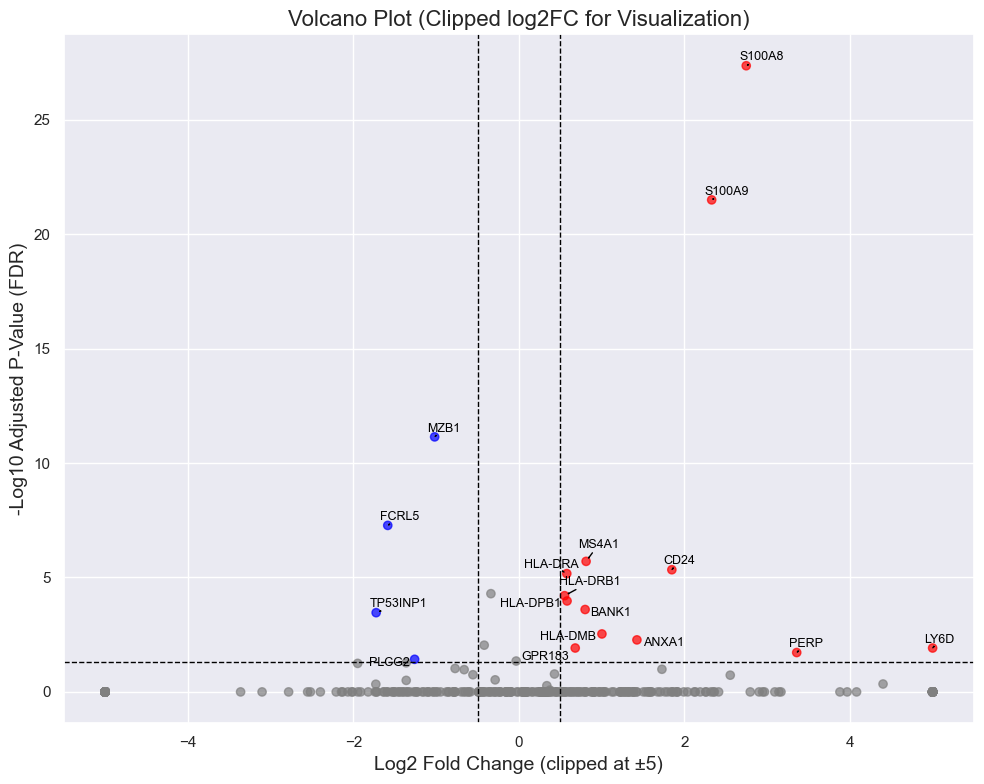

In [205]:
import numpy as np
import matplotlib.pyplot as plt
from adjustText import adjust_text

# Extract plotting data
log2fc_values = dge_results['Log2 Fold Change (Healthy vs Perio)'].values
log10_pvalues = -np.log10(np.maximum(dge_results['Adjusted P-Value (FDR)'].values, 1e-300))
gene_names = dge_results['Gene Name'].values
fdr_values = dge_results['Adjusted P-Value (FDR)'].values

# Clip log2FC for plotting only
log2fc_clipped = np.clip(log2fc_values, -5, 5)

# Color by true (unclipped) log2FC and significance
colors = ['red' if fc > 0.5 and p < 0.05 else
          'blue' if fc < -0.5 and p < 0.05 else
          'grey' for fc, p in zip(log2fc_values, fdr_values)]

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(log2fc_clipped, log10_pvalues, c=colors, alpha=0.7)

# Annotate genes of interest
texts = []
for x_clip, y, name, x_true in zip(log2fc_clipped, log10_pvalues, gene_names, log2fc_values):
    if name in filtered_gene_names:  
        texts.append(ax.text(x_clip, y, name, fontsize=9, color='black', ha='right'))

if texts:
    adjust_text(texts, only_move={'points': 'xy', 'text': 'xy'},
                arrowprops=dict(arrowstyle='->', color='black'))

# Cutoff lines
ax.axhline(-np.log10(0.05), linestyle='--', color='black', linewidth=1)
ax.axvline(0.5, linestyle='--', color='black', linewidth=1)
ax.axvline(-0.5, linestyle='--', color='black', linewidth=1)

# Labels
ax.set_xlabel('Log2 Fold Change (clipped at ±5)', fontsize=14)
ax.set_ylabel('-Log10 Adjusted P-Value (FDR)', fontsize=14)
ax.set_title('Volcano Plot (Clipped log2FC for Visualization)', fontsize=16)

plt.tight_layout()
plt.show()



In [20]:
adata.obs

,orig.ident,nCount_RNA,nFeature_RNA,tech,tissue,status,sex,age,ref,source,...,S.Score,G2M.Score,Phase,old.ident,integrated_snn_res.1,seurat_clusters,clusterCellTypes,generalCellTypes,fineCellTypes,assay
AAACCCACACCGTACG-1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1,HV150,1807.603861,1117,10x 3' RNAseq (V3),buccal,H,F,23,Williams 2021,GSE164241,...,-0.030961,-0.002085,G1,HV150,2,2,abT (CD8),Immune,abT (CD8),scSeq
AAACCCACATCGCTCT-1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1,HV150,8007.095465,2627,10x 3' RNAseq (V3),buccal,H,F,23,Williams 2021,GSE164241,...,-0.077662,-0.004026,G1,HV150,18,18,mDC,Immune,mDC,scSeq
AAACGAAAGGCTTAGG-1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1,HV150,5136.082067,1835,10x 3' RNAseq (V3),buccal,H,F,23,Williams 2021,GSE164241,...,-0.006036,-0.101804,G1,HV150,10,10,Monocyte,Immune,Monocyte,scSeq
AAAGTCCTCCTGTACC-1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1,HV150,6984.990662,3086,10x 3' RNAseq (V3),buccal,H,F,23,Williams 2021,GSE164241,...,0.022710,-0.061351,S,HV150,1,1,Fibroblast 1,Fibroblast,Fibroblast,scSeq
AAATGGAAGCAGCACA-1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1,HV150,1731.156586,983,10x 3' RNAseq (V3),buccal,H,F,23,Williams 2021,GSE164241,...,0.268633,-0.009602,S,HV150,2,2,gd T,Immune,gd T,scSeq
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
C1500_2_3,PDT3,611.000000,161,BD Rhapsody,gingiva,P_treated,M,55,Chen 2022,GSE171213,...,0.023174,-0.001486,S,PDT3,21,21,Epithelial 3,Epithelial,Epithelial,scSeq
C150e_2_3,PDT3,557.000000,358,BD Rhapsody,gingiva,P_treated,M,55,Chen 2022,GSE171213,...,-0.012698,-0.028312,G1,PDT3,2,2,gd T,Immune,gd T,scSeq
C1510_2_3,PDT3,4121.000000,1902,BD Rhapsody,gingiva,P_treated,M,55,Chen 2022,GSE171213,...,0.049123,-0.033868,S,PDT3,5,5,Endothelial 2,Endothelial,Endothelial,scSeq
C1514_2_3,PDT3,1613.000000,934,BD Rhapsody,gingiva,P_treated,M,55,Chen 2022,GSE171213,...,-0.002897,0.042199,G2M,PDT3,12,12,Endothelial 3,Endothelial,Endothelial,scSeq


In [44]:
# Define the cluster name you want to subset
cluster_name = "gingiva"  # or could be an integer if it's like 0, 1, etc.

# Subset the adata to include only cells of that cluster
adata_gingiva = adata[adata.obs['tissue'] == cluster_name].copy()

In [45]:
# Define the cluster name you want to subset
cluster_name = "Williams 2021"  # or could be an integer if it's like 0, 1, etc.

# Subset the adata to include only cells of that cluster
adata_Williams = adata_gingiva[adata_gingiva.obs['ref'] == cluster_name].copy()

In [46]:
# Subset the AnnData object to include only samples whose orig.ident starts with "HV" or "TM"
mask = adata_Williams.obs['orig.ident'].str.startswith(('HV', 'TM'))
adata_filtered = adata_Williams[mask].copy()

In [49]:
print(adata_filtered.X.sum(axis=0))  # Sum of counts per gene across all cells
print((adata_filtered.X > 0).sum(axis=0))  # Count of non-zero values per gene

[0. 0. 0. ... 0. 0. 0.]
[0 0 0 ... 0 0 0]


In [33]:
# Normalize and log-transform
sc.pp.normalize_total(adata_filtered, target_sum=1e6)
sc.pp.log1p(adata_filtered)

In [89]:
sc.pp.highly_variable_genes(adata_filtered, flavor='seurat_v3', n_top_genes=2000)

/gpfs/gsfs12/users/vasileiosionat2/conda/envs/squidpy/lib/python3.10/site-packages/legacy_api_wrap/__init__.py:82: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  return fn(*args_all, **kw)


In [90]:
adata_filtered = adata_filtered[:, adata_filtered.var['highly_variable']]

[0. 0. 0. ... 0. 0. 0.]


In [88]:
# Find genes with a sum above a small threshold
threshold = 1e-4
non_zero_genes = np.where(adata_filtered.X.sum(axis=0) > threshold)[0]

# Print the sums of these genes
print(f"Genes with non-zero sums: {non_zero_genes}")
print(f"Non-zero sums: {adata_filtered.X.sum(axis=0)[non_zero_genes]}")

Genes with non-zero sums: [    3     4     7 ... 33572 33573 33574]
Non-zero sums: [ 21.781876   2.         1.       ...  21.449677  37.659847 247.51833 ]


In [40]:
dense_data = adata_filtered.X.toarray()  # Convert sparse matrix to dense array
print(dense_data.sum(axis=0))  # Check the sum of counts per gene

AttributeError: 'numpy.ndarray' object has no attribute 'toarray'

In [95]:
res = sq.gr.ligrec(
    adata_filtered,
    n_perms=1000,
    cluster_key="generalCellTypes",
    copy=True,
    use_raw=False,
    transmitter_params={"categories": "ligand"},
    receiver_params={"categories": "receptor"},
)

100%|█████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:13<00:00, 71.84permutation/s]


In [97]:
res["means"].head(20)

cluster_1       Cycling                                                        \
cluster_2       Cycling Endothelial Epithelial Fibroblast    Immune       LEC   
source target                                                                   
IL1A   IL1R1   0.206208    0.182357   0.088528   0.434169  0.041766  0.056423   
CSF3   CSF3R   0.127943    0.076011    0.07702   0.076516  0.099221         0   
CSF2   CSF2RA         0           0          0          0         0         0   
CD70   CD27    0.326044     0.09124   0.088897   0.091464  0.275753  0.088199   
JAG1   NOTCH3  0.339173    0.184725   0.266827    0.29212  0.185482   0.18393   
JAG2   NOTCH3  0.180494    0.026047   0.108149   0.133442  0.026804  0.025251   
IL1RN  IL1R1   0.414343    0.390492   0.296663   0.642305  0.249901  0.264558   
IL3    CSF2RB         0           0          0          0         0         0   
KDR    CSF2RB  0.173482    0.458574   0.084517   0.089984  0.117102  0.095427   
KIT    CSF2RB  0.126215    0.411307    0.03725   0.042717  0.069836  0.048161   
IL1RN  IL1R2   0.307836    0.237461   0.338957    0.24181  0.254536  0.237256   
IL1B   IL1R2   1.628465     1.55809   1.659586   1.562438  1.575164  1.557885   
IL3    IL3RA          0           0          0          0         0         0   
IL1A   IL1R2   0.099701    0.029326   0.130822   0.033675  0.046401  0.029121   
DLL4   NOTCH4   0.05831    0.257154   0.018865   0.025478  0.017403  0.041523   
IL1B   IL1R1   1.734972    1.711121   1.617291   1.962933  1.570529  1.585186   
LIF    LIFR      0.0606    0.302908   0.040206   0.107966  0.030029   0.06896   
PDGFA  PDGFRA  0.422238    0.148549    0.15364    0.80874  0.145537  0.146796   
PDGFB  PDGFRA   0.31937    0.045681   0.050771   0.705872  0.042668  0.043928   
EFNA1  EPHA2   0.075669    0.102455   0.269788   0.049896  0.043774   0.07173   

cluster_1                                   Endothelial  ...      SMC  \
cluster_2     Melanocyte       SMC Stressed     Cycling  ... Stressed   
source target                                            ...            
IL1A   IL1R1    0.048549  0.104881        0    0.179589  ...        0   
CSF3   CSF3R           0  0.077196        0    0.378312  ...        0   
CSF2   CSF2RA          0         0        0    0.075573  ...        0   
CD70   CD27            0  0.091356        0    0.240497  ...        0   
JAG1   NOTCH3   0.246443  1.022518        0    0.395182  ...        0   
JAG2   NOTCH3   0.087765  0.863839        0    0.329157  ...        0   
IL1RN  IL1R1    0.256684  0.313017        0    0.181014  ...        0   
IL3    CSF2RB          0         0        0           0  ...        0   
KDR    CSF2RB   0.082735  0.100871        0    0.393563  ...        0   
KIT    CSF2RB   0.035469  0.053604        0    0.101373  ...        0   
IL1RN  IL1R2           0  0.237536        0    0.074507  ...        0   
IL1B   IL1R2           0  1.558164        0    0.073662  ...        0   
IL3    IL3RA           0         0        0           0  ...        0   
IL1A   IL1R2           0    0.0294        0    0.073082  ...        0   
DLL4   NOTCH4   0.022163  0.060361        0    0.157736  ...        0   
IL1B   IL1R1    1.577313  1.633645        0    0.180169  ...        0   
LIF    LIFR     0.048094  0.083055        0    0.033125  ...        0   
PDGFA  PDGFRA          0  0.150314        0    0.303333  ...        0   
PDGFB  PDGFRA          0  0.047446        0    0.384733  ...        0   
EFNA1  EPHA2    0.071972  0.094828        0    0.254454  ...        0   

cluster_1     Stressed                                                       \
cluster_2      Cycling Endothelial Epithelial Fibroblast   Immune       LEC   
source target                                                                 
IL1A   IL1R1         0           0          0          0        0         0   
CSF3   CSF3R         0           0          0          0        0         0   
CSF2   CSF2RA        0           0          0          0     

In [99]:
res["pvalues"].head(50)

cluster_1        Cycling                                                \
cluster_2        Cycling Endothelial Epithelial Fibroblast Immune  LEC   
source   target                                                          
IL1A     IL1R1       NaN         NaN        NaN        NaN    NaN  NaN   
CSF3     CSF3R       NaN         NaN        NaN        NaN    NaN  NaN   
CSF2     CSF2RA      NaN         NaN        NaN        NaN    NaN  NaN   
CD70     CD27        NaN         NaN        NaN        NaN    NaN  NaN   
JAG1     NOTCH3      NaN         NaN        NaN        NaN    NaN  NaN   
JAG2     NOTCH3      NaN         NaN        NaN        NaN    NaN  NaN   
IL1RN    IL1R1       NaN         NaN        NaN        NaN    NaN  NaN   
IL3      CSF2RB      NaN         NaN        NaN        NaN    NaN  NaN   
KDR      CSF2RB      NaN         NaN        NaN        NaN    NaN  NaN   
KIT      CSF2RB      NaN         NaN        NaN        NaN    NaN  NaN   
IL1RN    IL1R2       NaN         NaN        NaN        NaN    NaN  NaN   
IL1B     IL1R2       NaN         NaN        NaN        NaN    NaN  NaN   
IL3      IL3RA       NaN         NaN        NaN        NaN    NaN  NaN   
IL1A     IL1R2       NaN         NaN        NaN        NaN    NaN  NaN   
DLL4     NOTCH4      NaN         NaN        NaN        NaN    NaN  NaN   
IL1B     IL1R1       NaN         NaN        NaN        NaN    NaN  NaN   
LIF      LIFR        NaN         NaN        NaN        NaN    NaN  NaN   
PDGFA    PDGFRA      NaN         NaN        NaN        NaN    NaN  NaN   
PDGFB    PDGFRA      NaN         NaN        NaN        NaN    NaN  NaN   
EFNA1    EPHA2       NaN         NaN        NaN        NaN    NaN  NaN   
FRZB     WNT5A       NaN         NaN        NaN        NaN    NaN  NaN   
NRG2     ERBB3       NaN         NaN        NaN        NaN    NaN  NaN   
NRG1     ERBB3       NaN         NaN        NaN        NaN    NaN  NaN   
CSF3     CSF2RA      NaN         NaN        NaN        NaN    NaN  NaN   
IL11     IL11RA      NaN         NaN        NaN        NaN    NaN  NaN   
CSF2     CSF3R       NaN         NaN        NaN        NaN    NaN  NaN   
IL19     IL20RB      NaN         NaN        NaN        NaN    NaN  NaN   
IL20     IL20RB      NaN         NaN        NaN        NaN    NaN  NaN   
IL24     IL20RB      NaN         NaN        NaN        NaN    NaN  NaN   
IL22     IL22RA2     NaN         NaN        NaN        NaN    NaN  NaN   
CXCL12   ACKR3       NaN         NaN        NaN        NaN    NaN  NaN   
ADM      CALCRL      NaN         NaN        NaN        NaN    NaN  NaN   
CALCB    CALCRL      NaN         NaN        NaN        NaN    NaN  NaN   
ADM      CALCR       NaN         NaN        NaN        NaN    NaN  NaN   
         RAMP1       NaN         NaN        NaN        NaN    NaN  NaN   
CALCB    CALCR       NaN         NaN        NaN        NaN    NaN  NaN   
         RAMP1       NaN         NaN        NaN        NaN    NaN  NaN   
APLN     APLNR       NaN         NaN        NaN        NaN    NaN  NaN   
CCL20    CCR6        NaN         NaN        NaN        NaN    NaN  NaN   
CCL19    CCR7        NaN         NaN        NaN        NaN    NaN  NaN   
CCL21    CCR7        NaN         NaN        NaN        NaN    NaN  NaN   
CXCL6    CXCR1       NaN         NaN        NaN        NaN    NaN  NaN   
CXCL8    CXCR1       NaN         NaN        NaN        NaN    NaN  NaN   
EDN1     EDNRA       NaN         NaN        NaN        NaN    NaN  NaN   
EDN2     EDNRA       NaN         NaN        NaN        NaN    NaN  NaN   
ANXA1    FPR3        NaN         NaN        NaN        NaN    NaN  NaN   
XCL1     XCR1        NaN         NaN        NaN        NaN    NaN  NaN   
XCL2     XCR1        NaN         NaN        NaN        NaN    NaN  NaN   
TNF      HMOX1       NaN         NaN        NaN        NaN    NaN  NaN   
HLA-DRB1 LGMN        NaN         NaN        NaN        NaN    NaN  NaN   

cluster_1                                 Endothelial  ...      SMC Stressed 

In [32]:
res["metadata"].head(500)

aspect_intercell_source aspect_intercell_target  \
source target                                                   
EPOR   TRPC3               functional              functional   
FYN    TRPC4               functional              functional   
       TRPC6               functional              functional   
       TRPV4               functional              functional   
KL     TRPV5               functional              functional   
...                               ...                     ...   
NTF3   NTRK3               functional              functional   
EFNA3  EPHA3               functional              functional   
EFNA4  EPHA4               functional              functional   
EFNB1  EPHB1               functional              functional   
EFNB2  EPHB2               functional              functional   

              category_intercell_source category_intercell_target  \
source target                                                       
EPOR   TRPC3                     ligand                  receptor   
FYN    TRPC4                     ligand                  receptor   
       TRPC6                     ligand                  receptor   
       TRPV4                     ligand                  receptor   
KL     TRPV5                     ligand                  receptor   
...                                 ...                       ...   
NTF3   NTRK3                     ligand                  receptor   
EFNA3  EPHA3                     ligand                  receptor   
EFNA4  EPHA4                     ligand                  receptor   
EFNB1  EPHB1                     ligand                  receptor   
EFNB2  EPHB2                     ligand                  receptor   

              category_source_intercell_source  \
source target                                    
EPOR   TRPC3                 resource_specific   
FYN    TRPC4                 resource_specific   
       TRPC6                 resource_specific   
       TRPV4                 resource_specific   
KL     TRPV5                 resource_specific   
...                                        ...   
NTF3   NTRK3                 resource_specific   
EFNA3  EPHA3                 resource_specific   
EFNA4  EPHA4                 resource_specific   
EFNB1  EPHB1                 resource_specific   
EFNB2  EPHB2                 resource_specific   

              category_source_intercell_target  consensus_direction  \
source target                                                         
EPOR   TRPC3                 resource_specific                 True   
FYN    TRPC4                 resource_specific                False   
       TRPC6                 resource_specific                 True   
       TRPV4                 resource_specific                 True   
KL     TRPV5                 resource_specific                 True   
...                                        ...                  ...   
NTF3   NTRK3                 resource_specific                 True   
EFNA3  EPHA3                 resource_specific                 True   
EFNA4  EPHA4                 resource_specific                 True   
EFNB1  EPHB1                 resource_specific                 True   
EFNB2  EPHB2                 resource_specific                 True   

               consensus_inhibition  consensus_score_intercell_source  \
source target                                                           
EPOR   TRPC3                  False                                 1   
FYN    TRPC4                  False                                 2   
       TRPC6                  False                                 2   
       TRPV4                  False                                 2   
KL     TRPV5                  False                                 3   
...                             ...                               ...   
NTF3   NTRK3                  False                                21   
EFNA3  EPHA3                  False   

In [100]:
Xenium = sc.read_h5ad('/data/vasileiosionat2/Xenium/Drake_outputs/ccProcessed.h5ad')

/gpfs/gsfs12/users/vasileiosionat2/conda/envs/squidpy/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [101]:
Xenium.X

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 19861344 stored elements and shape (756482, 451)>

In [103]:
Xenium.obs

,cell_id,x_centroid,y_centroid,transcript_counts,control_probe_counts,control_codeword_counts,unassigned_codeword_counts,deprecated_codeword_counts,total_counts,cell_area,...,Lvl4_kmeans_Mel,Mel_leiden,KNN100_K10,KNN100_K12,spatial_expression_cluster,KNN50_K10,KNN30_K10,KNN10_K10,niche_knn50k10,niche_knn50k10_merged
cell_id,,,,,,,,,,,,,,,,,,,,,
aaaafkfa-1,aaaafkfa-1,897.109375,1332.185791,21,0,0,0,0,21,44.027345,...,NaN,NaN,2,10,2,3,4,4,Fib CT 2,Fibrous CT
aaabfapb-1,aaabfapb-1,887.724976,1353.138916,4,0,0,0,0,4,20.184844,...,NaN,NaN,2,10,2,3,4,4,Fib CT 2,Fibrous CT
aaagfdhe-1,aaagfdhe-1,896.825684,1353.078003,7,0,0,0,0,7,9.708594,...,NaN,NaN,2,10,2,3,4,4,Fib CT 2,Fibrous CT
aaahdjch-1,aaahdjch-1,884.860718,1348.416504,5,0,0,0,0,5,41.769533,...,NaN,NaN,2,10,2,3,4,4,Fib CT 2,Fibrous CT
aaaikifh-1,aaaikifh-1,894.474365,1345.850586,7,0,0,0,0,7,17.927032,...,NaN,NaN,2,10,2,3,4,4,Fib CT 2,Fibrous CT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
oimpocjl-1,oimpocjl-1,1548.523193,1297.322021,23,0,0,0,0,23,10.205313,...,NaN,NaN,1,9,1,8,8,3,Plasma-Fib CT,Plasma-Fib CT
oindfjhe-1,oindfjhe-1,1548.593140,1276.395020,27,0,0,0,0,27,16.165938,...,NaN,NaN,1,9,1,8,8,1,Plasma-Fib CT,Plasma-Fib CT
oinegfdb-1,oinegfdb-1,1545.742432,1284.771851,11,0,0,0,0,11,6.050938,...,NaN,NaN,1,9,1,8,8,4,Plasma-Fib CT,Plasma-Fib CT


In [111]:
sc.pp.highly_variable_genes(adata_B_final, flavor='seurat_v3', n_top_genes=2000)

/gpfs/gsfs12/users/vasileiosionat2/conda/envs/squidpy/lib/python3.10/site-packages/legacy_api_wrap/__init__.py:82: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  return fn(*args_all, **kw)


In [ ]:
adata_B_final = adata_B_final[:, adata_B_final.var['highly_variable']]

In [104]:
Xenium.obs['Lvl1'].unique().tolist()

['Other', 'Immune', 'Vascular', 'Fibroblast', 'Epithelial']

In [105]:
# Subset the AnnData object to include only samples whose orig.ident starts with "HV" or "TM"
mask = Xenium.obs['Lvl1'].str.startswith(('Immune', 'Vascular', 'Fibroblast', 'Epithelial'))
Xenium_filtered = Xenium[mask].copy()

/gpfs/gsfs12/users/vasileiosionat2/conda/envs/squidpy/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [106]:
Xenium_filtered.obs

,cell_id,x_centroid,y_centroid,transcript_counts,control_probe_counts,control_codeword_counts,unassigned_codeword_counts,deprecated_codeword_counts,total_counts,cell_area,...,Lvl4_kmeans_Mel,Mel_leiden,KNN100_K10,KNN100_K12,spatial_expression_cluster,KNN50_K10,KNN30_K10,KNN10_K10,niche_knn50k10,niche_knn50k10_merged
cell_id,,,,,,,,,,,,,,,,,,,,,
aadajopf-1,aadajopf-1,880.215515,1379.921143,21,0,0,0,0,21,41.001876,...,NaN,NaN,2,6,2,3,4,4,Fib CT 2,Fibrous CT
aadelfif-1,aadelfif-1,895.756714,1362.136353,10,0,0,0,0,10,16.075626,...,NaN,NaN,2,6,2,3,4,4,Fib CT 2,Fibrous CT
aaedmhbh-1,aaedmhbh-1,869.532410,1704.096802,93,0,0,0,0,93,45.156252,...,NaN,NaN,1,9,1,8,8,3,Plasma-Fib CT,Plasma-Fib CT
aaejelio-1,aaejelio-1,839.575256,1691.305054,26,0,0,0,0,26,25.739063,...,NaN,NaN,1,9,1,8,8,1,Plasma-Fib CT,Plasma-Fib CT
aaenabai-1,aaenabai-1,878.547424,1695.683960,114,0,0,0,0,114,59.199846,...,NaN,NaN,1,9,1,8,8,3,Plasma-Fib CT,Plasma-Fib CT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
oimpedpp-1,oimpedpp-1,1555.247559,1302.461670,81,0,0,0,0,81,24.158595,...,NaN,NaN,1,9,1,8,4,4,Plasma-Fib CT,Plasma-Fib CT
oimpocjl-1,oimpocjl-1,1548.523193,1297.322021,23,0,0,0,0,23,10.205313,...,NaN,NaN,1,9,1,8,8,3,Plasma-Fib CT,Plasma-Fib CT
oindfjhe-1,oindfjhe-1,1548.593140,1276.395020,27,0,0,0,0,27,16.165938,...,NaN,NaN,1,9,1,8,8,1,Plasma-Fib CT,Plasma-Fib CT


In [114]:
# List of ligand-receptor pairs
ligand_receptor_pairs = [
    ('ANPEP', 'SELE'),
    ('ANXA1', 'EGFR'),
    ('ANXA1', 'FPR1'),
    ('APOA5', 'LPL'),
    ('C3', 'CD19'),
    ('C3', 'ITGB2'),
    ('C3', 'VSIG4'),
    ('CAMP', 'EGFR'),
    ('CCL19', 'CCR7'),
    ('CCL5', 'ACKR1'),
    ('CCL5', 'SDC1'),
    ('CCN1', 'TLR2'),
    ('CCN1', 'ITGB5'),
    ('CCN1', 'TLR4'),
    ('CCN1', 'ITGB2'),
    ('CD274', 'PDCD1'),
    ('CD28', 'CD86'),
    ('CD28', 'CD247'),
    ('CD28', 'CD4'),
    ('CD34', 'SELL'),
    ('CD34', 'SELE'),
    ('CD70', 'CD27'),
    ('CD86', 'CD28'),
    ('CD86', 'CTLA4'),
    ('CFH', 'CFB'),
    ('CFH', 'SELL'),
    ('COL16A1', 'ITGA1'),
    ('COL17A1', 'ITGA1'),
    ('COL5A2', 'SDC1'),
    ('COL5A2', 'CD93'),
    ('COL5A2', 'ITGA1'),
    ('COL8A1', 'ITGA1'),
    ('CSF3', 'CSF3R'),
    ('CSF3', 'CSF2RA'),
    ('CXCL1', 'ACKR1'),
    ('CXCL10', 'ACKR1'),
    ('CXCL12', 'CXCR4'),
    ('CXCL12', 'CD4'),
    ('CXCL14', 'CXCR4'),
    ('CXCL2', 'ACKR1'),
    ('CXCL5', 'ACKR1'),
    ('CXCL6', 'ACKR1'),
    ('CXCL9', 'ACKR1'),
    ('EDN1', 'EDNRB'),
    ('EDN1', 'ADGRL4'),
    ('EDN1', 'EGFR'),
    ('GDF15', 'ERBB2'),
    ('HLA-DMB', 'CD4'),
    ('HLA-DQA2', 'LAG3'),
    ('HLA-DQA2', 'CD4'),
    ('HLA-DQB2', 'LAG3'),
    ('HLA-DRB5', 'LAG3'),
    ('HLA-DRB5', 'CD4'),
    ('ICAM1', 'EGFR'),
    ('ICAM1', 'IL2RA'),
    ('ICAM1', 'ITGB2'),
    ('IGF1', 'ITGB4'),
    ('IL1A', 'IL1R2'),
    ('IL1RN', 'IL1R2'),
    ('IL23A', 'IL23R'),
    ('IL23A', 'LILRB2'),
    ('IL33', 'IL1RL1'),
    ('ITGB2', 'ICAM1'),
    ('ITGB2', 'THY1'),
    ('KNG1', 'ITGB2'),
    ('KNG1', 'CD93'),
    ('LAMC2', 'ITGB4'),
    ('LPL', 'SDC1'),
    ('MMRN2', 'CD93'),
    ('MMRN2', 'CLEC14A'),
    ('PECAM1', 'PECAM1'),
    ('POSTN', 'ITGB5'),
    ('PRG4', 'TLR2'),
    ('PRG4', 'TLR4'),
    ('PTN', 'SDC1'),
    ('PTPRC', 'MRC1'),
    ('PTPRC', 'CD247'),
    ('PTPRC', 'CD4'),
    ('RETN', 'TLR4'),
    ('S100A12', 'TLR4'),
    ('SAA1', 'FPR1'),
    ('SAA1', 'TLR2'),
    ('SLAMF7', 'SLAMF7'),
    ('SLPI', 'CD4'),
    ('TFF2', 'CXCR4'),
    ('THBS2', 'SDC1'),
    ('THY1', 'ITGB2'),
    ('TNC', 'SDC1'),
    ('TNC', 'EGFR'),
    ('VCAN', 'EGFR'),
    ('VCAN', 'SELL'),
    ('VCAN', 'TLR2')
]
# Filter for ligand-receptor expressing cells
ligand_cells = {}
receptor_cells = {}

# Loop through each ligand-receptor pair
for ligand, receptor in ligand_receptor_pairs:
    # Assuming 'Xenium.raw.X' is a sparse CSR matrix, we convert the expression to a boolean array for each ligand and receptor
    ligand_cells_mask = (Xenium.raw.X[:, Xenium.raw.var_names == ligand].toarray() > 0).flatten()
    receptor_cells_mask = (Xenium.raw.X[:, Xenium.raw.var_names == receptor].toarray() > 0).flatten()

    # Add these boolean arrays to adata.obs as new columns
    Xenium.obs[f"{ligand}_expressed"] = ligand_cells_mask
    Xenium.obs[f"{receptor}_expressed"] = receptor_cells_mask

In [116]:
Xenium.obs.columns.unique().tolist()

['cell_id',
 'x_centroid',
 'y_centroid',
 'transcript_counts',
 'control_probe_counts',
 'control_codeword_counts',
 'unassigned_codeword_counts',
 'deprecated_codeword_counts',
 'total_counts',
 'cell_area',
 'nucleus_area_x',
 'orig.ident',
 'nucleus_area_y',
 'pt.id',
 'oct.id',
 'status',
 'status.2',
 'status.3',
 'age',
 'sex',
 'race',
 'region',
 'orig_reg',
 'total_area_mm2',
 'Lvl1',
 'Lvl2',
 'Lvl3',
 'epiHL',
 'fibHL',
 'endoHL',
 'immuneHL',
 'Lvl4',
 'Lvl1_IE',
 'Lvl2_IE',
 'lymphoidHL',
 'myeloidHL',
 'sample',
 '_scvi_batch',
 '_scvi_labels',
 'cc8',
 'cc14',
 'cc17',
 'Lvl2.5',
 'niche_cc14',
 'Lvl4_old',
 'T_leiden',
 'T_leiden2',
 'T_leiden3',
 'Lvl4_thesis',
 'F_leiden',
 'V_leiden',
 'V_leiden2',
 'Lvl5',
 'B_leiden',
 'Lvl4_kmeans_Mel',
 'Mel_leiden',
 'KNN100_K10',
 'KNN100_K12',
 'spatial_expression_cluster',
 'KNN50_K10',
 'KNN30_K10',
 'KNN10_K10',
 'niche_knn50k10',
 'niche_knn50k10_merged',
 'ANPEP_expressed',
 'SELE_expressed',
 'ANXA1_expressed',
 'EGFR_e

In [126]:
# Subset the AnnData object to include only samples whose orig.ident starts with "HV" or "TM"
mask = Xenium.obs['status.3'].str.startswith(('perio'))
Xenium_filtered = Xenium[mask].copy()

/gpfs/gsfs12/users/vasileiosionat2/conda/envs/squidpy/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [146]:
import numpy as np
import pandas as pd

# Set a threshold to define "same niche" (e.g., 90%)
threshold = 0.7

# Initialize an empty list to store results for each ligand-receptor pair
interaction_results = []

# Loop through each ligand-receptor pair
for ligand, receptor in ligand_receptor_pairs:
    
    # Get ligand and receptor-expressing cells in the current sample
    ligand_cells_mask = Xenium_filtered.obs[f"{ligand}_expressed"] == True
    receptor_cells_mask = Xenium_filtered.obs[f"{receptor}_expressed"] == True
    
    # Extract the niche information for ligand- and receptor-expressing cells
    ligand_niche = Xenium_filtered.obs.loc[ligand_cells_mask, 'niche_knn50k10_merged']
    receptor_niche = Xenium_filtered.obs.loc[receptor_cells_mask, 'niche_knn50k10_merged']
    
    # Calculate the proportion of ligand and receptor cells in each niche
    ligand_niche_counts = ligand_niche.value_counts(normalize=True)
    receptor_niche_counts = receptor_niche.value_counts(normalize=True)
    
    # Determine the most common niche for ligand and receptor-expressing cells
    ligand_majority_niche = ligand_niche_counts.idxmax() if len(ligand_niche_counts) > 0 else None
    receptor_majority_niche = receptor_niche_counts.idxmax() if len(receptor_niche_counts) > 0 else None
    
    # Calculate the proportion of ligand and receptor cells in their respective majority niches
    ligand_majority_proportion = ligand_niche_counts.max() if len(ligand_niche_counts) > 0 else 0
    receptor_majority_proportion = receptor_niche_counts.max() if len(receptor_niche_counts) > 0 else 0

    # Define if the ligand and receptor-expressing cells are in the same niche (based on the threshold)
    if ligand_majority_niche == receptor_majority_niche :
        niche_status = "Same Niche"
    else:
        niche_status = "Different Niche"
    
    # Store the results for the current ligand-receptor pair
    interaction_results.append({
        'Ligand': ligand,
        'Receptor': receptor,
        'Niche Status': niche_status,
        'Ligand Cells in Niche': len(ligand_niche),
        'Receptor Cells in Niche': len(receptor_niche),
        'Ligand Majority Niche': ligand_majority_niche,
        'Receptor Majority Niche': receptor_majority_niche,
        'Ligand Majority Proportion': ligand_majority_proportion,
        'Receptor Majority Proportion': receptor_majority_proportion
    })

# Convert the results into a Pandas DataFrame
interaction_df = pd.DataFrame(interaction_results)

# Optionally, save the results to a CSV
# interaction_df.to_csv('ligand_receptor_niche_status.csv', index=False)

# Display the results
print(interaction_df)


   Ligand Receptor     Niche Status  Ligand Cells in Niche  \
0   ANPEP     SELE  Different Niche                  19126   
1   ANXA1     EGFR       Same Niche                 238599   
2   ANXA1     FPR1  Different Niche                 238599   
3   APOA5      LPL  Different Niche                    181   
4      C3     CD19       Same Niche                  49450   
..    ...      ...              ...                    ...   
87    TNC     SDC1  Different Niche                  36165   
88    TNC     EGFR       Same Niche                  36165   
89   VCAN     EGFR  Different Niche                  99320   
90   VCAN     SELL  Different Niche                  99320   
91   VCAN     TLR2  Different Niche                  99320   

    Receptor Cells in Niche Ligand Majority Niche Receptor Majority Niche  \
0                     18675            Fibrous CT           Plasma-Fib CT   
1                     72923                Epi-CT                  Epi-CT   
2                      7

In [147]:
# Display rows from index 60 to 90 (inclusive of 60, exclusive of 90)
print(interaction_df.iloc[00:60])

      Ligand Receptor     Niche Status  Ligand Cells in Niche  \
0      ANPEP     SELE  Different Niche                  19126   
1      ANXA1     EGFR       Same Niche                 238599   
2      ANXA1     FPR1  Different Niche                 238599   
3      APOA5      LPL  Different Niche                    181   
4         C3     CD19       Same Niche                  49450   
5         C3    ITGB2       Same Niche                  49450   
6         C3    VSIG4       Same Niche                  49450   
7       CAMP     EGFR  Different Niche                    205   
8      CCL19     CCR7       Same Niche                  16985   
9       CCL5    ACKR1  Different Niche                  30143   
10      CCL5     SDC1  Different Niche                  30143   
11      CCN1     TLR2  Different Niche                  63701   
12      CCN1    ITGB5  Different Niche                  63701   
13      CCN1     TLR4  Different Niche                  63701   
14      CCN1    ITGB2  Di

In [161]:
import numpy as np
import pandas as pd
from scipy.spatial import distance

# Set a small radius for measuring receptor clustering
radius = 50  # Example radius in micrometers

# Set the number of permutations
num_permutations = 100

# Initialize an empty list to store results
results = []

# Get unique imageIDs (samples)
image_ids = Xenium.obs['sample'].unique()

# Select the first ligand-receptor pair for testing
ligand, receptor = ligand_receptor_pairs[8]

# Iterate through all samples
for sample_name in image_ids:
    # Filter the data for the selected sample
    adata_sample = Xenium[Xenium.obs['sample'] == sample_name]

    # Extract ligand-expressing cells based on the mask
    ligand_cells_mask = adata_sample.obs[f"{ligand}_expressed"] == True
    ligand_coords = adata_sample.obs.loc[ligand_cells_mask, ['x_centroid', 'y_centroid']].to_numpy()

    # Extract receptor-expressing cells based on the mask
    receptor_cells_mask = adata_sample.obs[f"{receptor}_expressed"] == True
    receptor_coords = adata_sample.obs.loc[receptor_cells_mask, ['x_centroid', 'y_centroid']].to_numpy()

    # Check if there are enough ligand-expressing cells and receptor-expressing cells
    if ligand_coords.shape[0] >= 50 and receptor_coords.shape[0] > 0:
        # Count how many receptor-expressing cells are within the radius of each ligand-expressing cell
        receptor_counts = []

        for ligand_cell in ligand_coords:
            # Calculate the Euclidean distances between the ligand cell and all receptor cells
            distances = np.linalg.norm(receptor_coords - ligand_cell, axis=1)
            # Count the number of receptor cells within the radius
            count_within_radius = np.sum(distances <= radius)
            receptor_counts.append(count_within_radius)

        # Observed number of receptor cells within radius (mean over all ligand cells)
        observed_receptor_count = np.mean(receptor_counts)

        # Perform a permutation test to assess statistical significance
        permuted_receptor_counts = []
        for _ in range(num_permutations):
            # Randomly permute the receptor coordinates
            permuted_receptor_coords = np.random.permutation(receptor_coords)
            
            # Count how many permuted receptor cells are within the radius of each ligand cell
            permuted_counts = []
            for ligand_cell in ligand_coords:
                distances = np.linalg.norm(permuted_receptor_coords - ligand_cell, axis=1)
                permuted_counts.append(np.sum(distances <= radius))
            permuted_receptor_counts.append(np.mean(permuted_counts))

        # Calculate p-value as the proportion of permuted receptor counts greater than or equal to the observed count
        p_value = np.mean(np.array(permuted_receptor_counts) >= observed_receptor_count)

        # Append the result for this pair
        results.append({
            'Sample': sample_name,
            'Ligand': ligand,
            'Receptor': receptor,
            'Observed Receptor Count': observed_receptor_count,
            'P-Value': p_value
        })

    else:
        # If there are not enough ligand or receptor cells, append a placeholder result
        results.append({
            'Sample': sample_name,
            'Ligand': ligand,
            'Receptor': receptor,
            'Observed Receptor Count': 'N/A',
            'P-Value': 'N/A'
        })

# Convert results into a Pandas DataFrame
df_results = pd.DataFrame(results)

# Optionally, save the raw results to a CSV file
# df_results.to_csv('ligand_receptor_radius_counts_with_permutation.csv', index=False)

# Display the results
print(df_results)

          Sample Ligand Receptor Observed Receptor Count P-Value
0         s1r1_a  CCL19     CCR7                2.542435     1.0
1         s1r1_b  CCL19     CCR7                2.506897     1.0
2           s1r2  CCL19     CCR7                2.503275     1.0
3           s1r3  CCL19     CCR7                5.090749     1.0
4           s1r5  CCL19     CCR7                1.820093     1.0
5           s1r6  CCL19     CCR7                     N/A     N/A
6     s2r1_HV203  CCL19     CCR7                3.834264     1.0
7     s2r1_HV207  CCL19     CCR7                8.234332     1.0
8     s2r2_HV137  CCL19     CCR7                2.425373     1.0
9     s2r2_HV184  CCL19     CCR7               12.396226     1.0
10          s2r3  CCL19     CCR7                4.598485     1.0
11        s2r4_a  CCL19     CCR7                0.690265     1.0
12        s2r4_b  CCL19     CCR7                4.513453     1.0
13          s2r5  CCL19     CCR7                1.759916     1.0
14        s2r7_a  CCL19  

In [148]:
import numpy as np
import pandas as pd
from sklearn.metrics import pairwise_distances

# Set a maximum distance threshold 
max_distance = 1000  

# Initialize an empty list to store results
results = []

# Get unique sample names (assuming the column is 'sample' in adata.obs)
image_ids = Xenium.obs['sample'].unique()

for sample_name in image_ids:
    # Filter the data for the selected sample
    adata_sample = Xenium[Xenium.obs['sample'] == sample_name]

    # Loop through each ligand-receptor pair
    for ligand, receptor in ligand_receptor_pairs:
        # Extract ligand-expressing cells based on the mask
        ligand_cells_mask = adata_sample.obs[f"{ligand}_expressed"] == True
        ligand_coords = adata_sample.obs.loc[ligand_cells_mask, ['x_centroid', 'y_centroid']].to_numpy()

        # Check if there are enough ligand-expressing cells (e.g., more than 200)
        if ligand_coords.shape[0] >= 200:
            # Extract receptor-expressing cells based on the mask
            receptor_cells_mask = adata_sample.obs[f"{receptor}_expressed"] == True
            receptor_coords = adata_sample.obs.loc[receptor_cells_mask, ['x_centroid', 'y_centroid']].to_numpy()

            # Calculate pairwise Euclidean distances between ligand-expressing and receptor-expressing cells
            if receptor_coords.shape[0] > 0:  # Ensure there are receptor-expressing cells
                dist_matrix = pairwise_distances(ligand_coords, receptor_coords, metric='euclidean')

                # Find receptor cells within the maximum distance for any ligand cell
                valid_cells_indices = np.unique(np.where(dist_matrix <= max_distance)[1])

                # Filter the valid receptor coordinates within the threshold
                valid_receptor_cells = receptor_coords[valid_cells_indices]

                # Count the number of unique receptor cells within the threshold
                num_unique_receptor_cells = len(valid_receptor_cells)

                # Calculate the average distance for the valid receptor cells
                if num_unique_receptor_cells > 0:
                    valid_distances = dist_matrix[:, valid_cells_indices]
                    avg_distance = valid_distances[valid_distances <= max_distance].mean()
                else:
                    avg_distance = None

                # Append the results for this pair
                results.append({
                    'Sample': sample_name,
                    'Ligand': ligand,
                    'Receptor': receptor,
                    'Average Distance': avg_distance,
                    'Unique Receptor Cells Count': num_unique_receptor_cells
                })
            else:
                # If there are no receptor-expressing cells, append a placeholder result
                results.append({
                    'Sample': sample_name,
                    'Ligand': ligand,
                    'Receptor': receptor,
                    'Average Distance': 'N/A',
                    'Unique Receptor Cells Count': 0
                })
        else:
            # If there are not enough ligand cells, append a placeholder result
            results.append({
                'Sample': sample_name,
                'Ligand': ligand,
                'Receptor': receptor,
                'Average Distance': 'N/A',
                'Unique Receptor Cells Count': 'Not enough ligand cells'
            })

# Convert results into a Pandas DataFrame
df_results = pd.DataFrame(results)

# Optionally, save the raw results to a CSV file
# df_results.to_csv('ligand_receptor_distances.csv', index=False)

# Display the results
print(df_results)


KeyboardInterrupt: 